# Requirements

In case an NVIDIA GPU is available on your machine, we recommend to install CUDA as an additional requirement. This greatly accelerates the machine-learning-based evaluation in this section. **Do not execute this, if you do not have such a GPU!**

```sh
pip install --upgrade --extra-index-url=https://pypi.nvidia.com "cuml-cu12==25.6.*"
```

You also might need to [expose the GPU to the docker compose container](https://docs.docker.com/engine/containers/gpu/). Since we used a Slurm-based cluster for the steps using CUDA, we were not able to test this.

In [1]:
import itertools
import os
import pathlib

from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot
import numpy
import polars
from tqdm.notebook import tqdm

from utils import list_code
from list_scenarios import (
    list_scenarios,
    list_scenarios_full,
    PROTOCOLS,
    LINK_LAYERS,
    LINK_LAYER_MODES,
    BLOCKWISE,
    NETWORK_SETUPS,
    DATA_FORMATS,
    DNS_FORMATS,
    RANDIV_PAD,
)

EVALUATION_PATH = pathlib.Path.cwd()
INPUT_PATH = EVALUATION_PATH / "output_dataset"

os.environ["EVALUATION_PATH"] = str(EVALUATION_PATH)
os.environ["INPUT_PATH"] = str(INPUT_PATH)

FEATURE_VECTORS = ["binvec", #"word2vec"
                  ]


PROTOCOLS_READABLE = {
    "coap": "CoAP",
    "coaps": "CoAPS",
    "https": "HTTPS",
    "oscore-base": "OSCORE",
    "oscore_base": "OSCORE",
    "oscore": "Onion\nOSCORE",
}
LINK_LAYER_READABLE = {
    "": "eth",
    "-schc": "schc",
}
LINK_LAYER_MODE_READABLE = {
    "": "",
    "-min-rules": "min_rules",
    "-peer-based": "peer_based",
}
BLOCKWISE_READABLE = {
    "": "1024",
    "_b64": "64",
}

# Feature Importances

## Running Permutation Importances Determination in TMUX

In [19]:
list_code(EVALUATION_PATH / "perm_importance.sh")

#! /bin/bash
#
# perm_importance.sh
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license.
#

SCRIPT_DIR=$( cd -- "$( dirname -- "$(realpath "$0")" )" &> /dev/null && pwd )
VENV=${VENV:-"${SCRIPT_DIR}"/.env}
INPUT_PATH="${INPUT_PATH:-${SCRIPT_DIR}/output_dataset}"
vec="binvec"
cls="rf"
args=""


while getopts ":c:D:d:l:n:p:rR:v:" opt; do
    case "${opt}" in
    c)  cls="${OPTARG}";;
    p)  prots="${prots}_${OPTARG}"; args="${args} -p ${OPTARG}";;
    D)  data="${data}_${OPTARG}"; args="${args} -D ${OPTARG}";;
    d)  dns="${dns}_${OPTARG}"; args="${args} -d ${OPTARG}";;
    l)  link_layer="${link_layer}_${OPTARG}"; args="${args} -l ${OPTARG}";;
    n)  network_setups="${network_setups}_${OPTARG}"; args="${args} -n ${OPTARG}";;
    r)  args="${args} -r";;
    R)  args="${args} -R ${OPTARG}";;
    v)  vec="${OPTARG}";;
    *)  prots="${prots}_${OPTARG}"; args="${args} -p ${OPTARG}";;
    esac
done

export POLARS_FORCE_NEW_STREAMING=1

"${VENV}"/bin/python "${SCRIPT_DIR}"/list_scenarios.py $args | while read scenario; do
    "${VENV}"/bin/python "${SCRIPT_DIR}"/perm_importance.py -c "${cls}" -v "${vec}" "${scenario}"
done &> "${INPUT_PATH}/perm_importance_${cls}_${step}${prots}${network_setups}${link_layer}${data}${dns}_${vec}_${SLURM_JOB_ID}.log"

In [20]:
list_code(EVALUATION_PATH / "perm_importance.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import contextlib
import csv
import functools
import itertools
import os
import numbers
import pathlib
import psutil
import multiprocessing
import sys
import time
import traceback
import warnings

import numpy
import polars
import polars.exceptions

from list_scenarios import (
    list_scenarios_full,
    parse_scenario_name,
)

import sklearn.inspection._permutation_importance as sk_perm_imp


EVALUATION_DIR = pathlib.Path.cwd()
INPUT_PATH = pathlib.Path(
    os.environ.get("INPUT_PATH", EVALUATION_DIR / "output_dataset")
)

TEST_SIZE = 0.2
REPEATS = 2
SCORINGS = [
    "accuracy",
    # "precision",
    # "recall",
    "f1",
    # "balanced_accuracy",
    # "roc_auc",
]
CLASSIFIERS = [
    "lr",
    "knn",
    "svm",
    "dt",
    "rf",
    "ab",
]
FIELD_NAMES = [
    "protocol",
    "link_layer",
    "link_layer_mode",
    "blocksize",
    "network_setup",
    "data_format",
    "dns_format",
    "randiv_pad",
    "vector_type",
    "classifier",
    "classifier_args",
    "repeats",
    "job_id",
    "start",
    "stop",
    "feature",
    "accuracy_mean",
    "accuracy_std",
    "precision_mean",
    "precision_std",
    "recall_mean",
    "recall_std",
    "f1_mean",
    "f1_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "roc_auc_mean",
    "roc_auc_std",
]

LINK_LAYER_READABLE = {
    "": "eth",
    "-schc": "schc",
}
LINK_LAYER_MODE_READABLE = {
    "": "",
    "-min-rules": "min_rules",
    "-peer-based": "peer_based",
}
BLOCKWISE_READABLE = {
    "": "1024",
    "_b64": "64",
}

CLASSIFIER_READABLE = {
    "lr": "Logistic Regression",
    "knn": "K-Nearest Neighbors",
    "svm": "Support Vector Machine",
    "dt": "Decision Tree",
    "rf": "Random Forest (Ensemble Learning III)",
    "ab": "AdaBoost (SAMME)"
}

RANDOM_SEED = 0x61596c9b

CLASSIFIER_ARGS = {
    "lr": {"max_iter": 2800, "random_state": RANDOM_SEED},
    "knn": {
        "algorithm": "brute",
        "n_jobs": -1,
    },
    "dt": {"random_state": RANDOM_SEED},
    "svm": {"C": 0.01, "random_state": RANDOM_SEED},
    "rf": {
        "n_estimators": 250,
        "max_depth": 9,
        "random_state": RANDOM_SEED,
    },
    "ab": {
        "n_estimators": 250,
        "random_state": RANDOM_SEED,
    },
}


@contextlib.contextmanager
def fit_lr(x, y):
    lr = sk_linear_model.LogisticRegression(**CLASSIFIER_ARGS["lr"])
    lr.fit(x, y)
    try:
        yield lr
    finally:
        del lr


@contextlib.contextmanager
def fit_knn(x, y):
    knn = sk_neighbors.KNeighborsClassifier(**CLASSIFIER_ARGS["knn"])
    knn.fit(x, y)
    try:
        yield knn
    finally:
        del knn


@contextlib.contextmanager
def fit_svm(x, y):
    svm = sk_svm.LinearSVC(**CLASSIFIER_ARGS["svm"])
    svm.fit(x, y)
    try:
        yield svm
    finally:
        del svm


@contextlib.contextmanager
def fit_dt(x, y):
    dt = sk_tree.DecisionTreeClassifier(**CLASSIFIER_ARGS["dt"])
    dt.fit(x, y)
    try:
        yield dt
    finally:
        del dt


@contextlib.contextmanager
def fit_rf(x, y):
    rf = sk_ensemble.RandomForestClassifier(**CLASSIFIER_ARGS["rf"])
    rf.fit(x, y)
    try:
        yield rf
    finally:
        del rf


@contextlib.contextmanager
def fit_ab(x, y):
    ab = sk_ensemble.AdaBoostClassifier(**CLASSIFIER_ARGS["ab"])
    ab.fit(x, y)
    try:
        yield ab
    finally:
        del ab


FIT = {
    "lr": fit_lr,
    "knn": fit_knn,
    "svm": fit_svm,
    "dt": fit_dt,
    "rf": fit_rf,
    "ab": fit_ab,
}


def process_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss


def str_classifier_args(classifier):
    args = ",".join(
        f"{k}={v}"
        for k, v
        in CLASSIFIER_ARGS[classifier].items()
        if k != "output_type"
    )
    if args:
        return args
    return None


def configure_cuml():
    sklea

In [21]:
%%bash

tmux new-session -s "cross_validate" -d "source '${EVALUATION_PATH}'/.env/bin/activate && INPUT_PATH='${INPUT_PATH}' '${EVALUATION_PATH}/perm_importance.sh'"

## Alternative: Run on a slurm-based cluster

If you have access to a slurm-based cluster with GPUs, we also provided a batch script for that.

In [22]:
list_code(EVALUATION_PATH / "perm_importance_slurm.sh")

#!/bin/bash
#
# training_slurm.sh
# Copyright (C) 2025 TU Dresden
#
# Distributed under terms of the MIT license.
#

#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00
#SBATCH hetjob
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem-per-cpu=376260
#SBATCH --gres=gpu:2
#SBATCH --time=144:00:00

module purge
module load release/24.10 GCCcore/13.3.0 CUDA/12.6.0 Python/3.12.3

export INPUT_PATH=/data/horse/ws/male646f-pivot-eval/
export VENV="${INPUT_PATH}"/.env-cuml

. "${VENV}"/bin/activate && \
  	pip install --upgrade uv &&
  	uv pip install --upgrade -r "${PWD}"/requirements.txt &&
  	pip install --upgrade --extra-index-url=https://pypi.nvidia.com "cuml-cu12==25.6.*"
# installing from pypi.nvidia.com does not work with uv...

srun "${PWD}"/perm_importance.sh -r -c rf -p coaps          -D "json" -d "dns_message" -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p coap -p https  -D "json" -d "dns_message" -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p oscore         -D "json" -d "dns_message" -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p oscore-base    -D "json" -d "dns_message" -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p coaps          -D "cbor" -d "dns_message" -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p coap -p https  -D "cbor" -d "dns_message" -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p oscore         -D "cbor" -d "dns_message" -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p oscore-base    -D "cbor" -d "dns_message" -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p coaps          -D "json" -d "dns_cbor"    -v binvec : \
     "${PWD}"/perm_importance.sh -r -c rf -p coap -p https  -D "json" -d "dns_cbor"    -v binvec :

## Merge Permutation Importances Results

TBD, see `capella`

## Collect Data

In [23]:
files = []
for vector in FEATURE_VECTORS:
    if vector == "word2vec":
        continue
    for scenario in list_scenarios():
        file = INPUT_PATH / f"{scenario}.{vector}.rf.perm_imp.csv"
        if file.exists() and file.stat().st_size > 0:
            files.append(file)

lf = polars.concat(
    map(
        lambda f: polars.scan_csv(
            f,
            schema_overrides={
                "protocol": polars.String,
                "link_layer": polars.String,
                "link_layer_mode": polars.String,
                "blocksize": polars.Int16,
                "network_setup": polars.String,
                "data_format": polars.String,
                "dns_format": polars.String,
                "randiv_pad": polars.Int8,
                "vector_type": polars.String,
                "classifier": polars.String,
                "classifier_args": polars.String,
                "job_id": polars.Int64,
                "start": polars.Datetime,
                "stop": polars.Datetime,
                "feature": polars.Int16,
                "accuracy_mean": polars.Float64,
                "accuracy_std": polars.Float64,
                "precision_mean": polars.Float64,
                "precision_std": polars.Float64,
                "recall_mean": polars.Float64,
                "recall_std": polars.Float64,
                "f1_mean": polars.Float64,
                "f1_std": polars.Float64,
                "balanced_accuracy_mean": polars.Float64,
                "balanced_accuracy_std": polars.Float64,
                "roc_auc_mean": polars.Float64,
                "roc_auc_std": polars.Float64,
            },
            separator=";",
        ).select(
            [
                "protocol",
                "link_layer",
                "link_layer_mode",
                "blocksize",
                "network_setup",
                "data_format",
                "dns_format",
                "randiv_pad",
                "vector_type",
                "classifier",
                "classifier_args",
                "job_id",
                "start",
                "stop",
                "feature",
                "accuracy_mean",
                "accuracy_std",
                "f1_mean",
                "f1_std",
            ]
        ),
        files,
    )
).with_columns(polars.col("link_layer_mode").fill_null(""))
del files

METRICS_READABLE = {
    "accuracy": "Accuracy",
#    "f1": "$F_1$ score",
}
CLASSIFIERS = [
    # "nb",
    #"dt",
    #"lr",
    #"knn",
    #"svm",
    "rf"
]
CLASSIFIER_READABLE = {
    "nb": "Naïve Bayes",
    "lr": "Logistic Regression",
    "knn": "K-Nearest Neighbors",
    "svm": "Support Vector Machine",
    "dt": "Decision Tree",
    "rf": "Random Forest",
}
FEATURE_VECTORS = [
    "binvec",
    #"word2vec"
]

agg_abl = {
    vector: {
        cls: {
            (l2, l2_mode, blk, prot, stp, randiv_pad): {
                metric: {} for metric in METRICS_READABLE
            }
            for l2 in LINK_LAYERS
            for l2_mode in LINK_LAYER_MODES
            for blk in BLOCKWISE
            for prot in PROTOCOLS
            for stp in NETWORK_SETUPS
            for randiv_pad in RANDIV_PAD
        }
        for cls in CLASSIFIERS
    }
    for vector in FEATURE_VECTORS
}
agg_score = {
    vector: {
        cls: {
            (l2, l2_mode, blk, prot, stp, data, dns, randiv_pad): {
                metric: {} for metric in METRICS_READABLE
            }
            for l2 in LINK_LAYERS
            for l2_mode in LINK_LAYER_MODES
            for blk in BLOCKWISE
            for prot in PROTOCOLS
            for stp in NETWORK_SETUPS
            for data in DATA_FORMATS
            for dns in DNS_FORMATS
            for randiv_pad in RANDIV_PAD
        }
        for cls in CLASSIFIERS
    }
    for vector in FEATURE_VECTORS
}

for vector, cls, metric, (scenario, prot, l2, stp, l2_mode, data, dns, blk, randiv_pad) in tqdm(
    list(
        itertools.product(
            FEATURE_VECTORS,
            CLASSIFIERS,
            METRICS_READABLE,
            list_scenarios_full(filter_randiv_pad=True),
        )
    )
):
    agg_abl[vector][cls][l2, l2_mode, blk, prot, stp, randiv_pad][metric][
        (data, dns)
    ] = lf.filter(
        (polars.col("data_format") == data)
        & (polars.col("dns_format") == dns)
        & (polars.col("vector_type") == vector)
        & (polars.col("link_layer") == LINK_LAYER_READABLE[l2])
        & (polars.col("link_layer_mode") == LINK_LAYER_MODE_READABLE[l2_mode])
        & (polars.col("protocol") == prot)
        & (polars.col("blocksize") == int(BLOCKWISE_READABLE[blk]))
        & (polars.col("network_setup") == stp)
        & (polars.col("randiv_pad") == int(randiv_pad == "_randiv_pad"))
        & (polars.col("classifier") == cls)
    ).unique(
        subset=[
            "protocol",
            "link_layer",
            "link_layer_mode", 
            "blocksize",
            "network_setup",
            "data_format",
            "dns_format",
            "randiv_pad",
            "vector_type",
            "classifier",
            "feature",
        ],
        keep="last",
    ).rename(
        {f"{metric}_mean": f"{metric}"}
    ).select(["feature", f"{metric}"]).sort(["feature"]).collect()
    if agg_abl[vector][cls][l2, l2_mode, blk, prot, stp, randiv_pad][metric][
        (data, dns)
    ].is_empty():
        del agg_abl[vector][cls][l2, l2_mode, blk, prot, stp, randiv_pad][metric][
            (data, dns)
        ]
    if not agg_score[vector][cls][l2, l2_mode, blk, prot, stp, data, dns, randiv_pad][metric]:
        score_lf = polars.scan_csv(
            INPUT_PATH / f"{scenario}.cross_val.csv",
            separator=";",
        ).filter(polars.col("classifier") == "rf").select(
            ["f1_score" if metric == "f1" else metric]
        ).with_columns(
            *[
                polars.col("f1_score" if metric == "f1" else metric)
                    .str.strip_chars_start("[")
                    .str.strip_chars_end("]")
                    .str.split(",")
                    .list.eval(polars.element().str.strip_chars(" "))
                    .cast(polars.List(polars.Float64))
            ]
        ).with_columns(
            polars.col(
                    "f1_score" if metric == "f1" else metric
                ).list.mean().alias(f"mean"),
            polars.col(
                "f1_score" if metric == "f1" else metric
            ).list.std().alias(f"std"),
        ).select([f"mean", f"std"])
        agg_score[vector][cls][
            l2, l2_mode, blk, prot, stp, data, dns, randiv_pad
        ][metric] = score_lf.collect().to_dicts()[0]

  0%|          | 0/296 [00:00<?, ?it/s]

## Plotting

### Random Forest: “Ethernet”, D1, Blocksize: 1024

#### HTTPS

##### [Detail, D1, Block Size: 1024](plots/perm_imp_binvec_rf_d1_https_eth_1024.pdf) ($x$ max: 9191)

<Figure size 805.516x156.881 with 0 Axes>

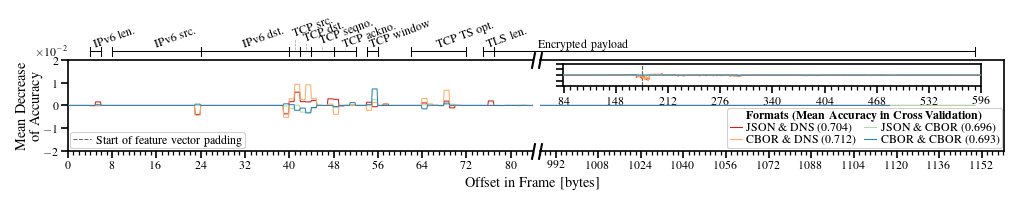

#### CoAP

##### [Detail, D1, Block Size: 1024](plots/perm_imp_binvec_rf_d1_coap_eth_1024.pdf) ($x$ max: 8719)

<Figure size 805.516x156.881 with 0 Axes>

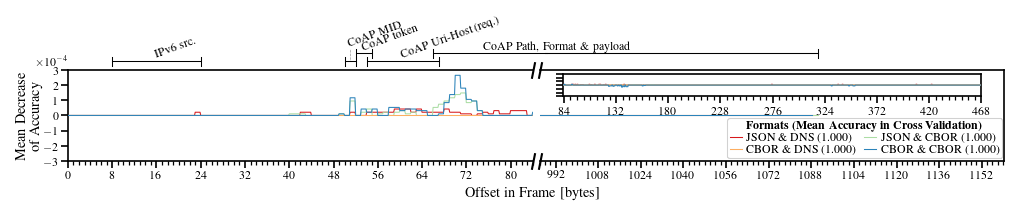

#### CoAPS

##### [Detail, D1, Block Size: 1024](plots/perm_imp_binvec_rf_d1_coaps_eth_1024.pdf) ($x$ max: 8951)

<Figure size 805.516x156.881 with 0 Axes>

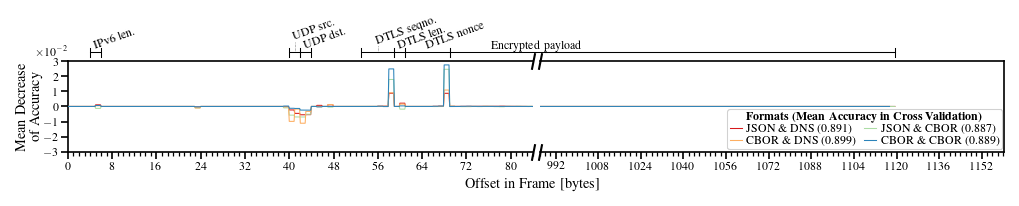

#### Onion OSCORE

##### [Detail, D1, Block Size: 1024](plots/perm_imp_binvec_rf_d1_oscore_eth_1024.pdf) ($x$ max: 8847)

<Figure size 805.516x156.881 with 0 Axes>

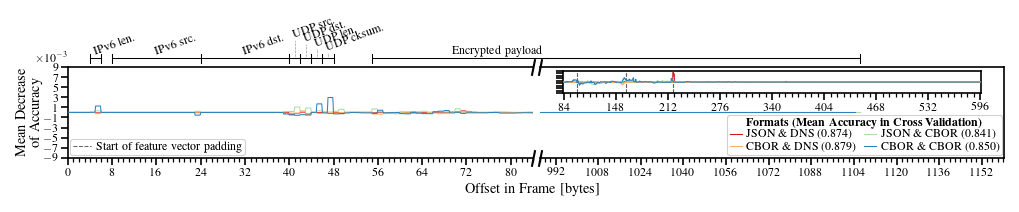

#### OSCORE

##### [Detail, D1, Block Size: 1024](plots/perm_imp_binvec_rf_d1_oscore-base_eth_1024.pdf) ($x$ max: 8847)

<Figure size 805.516x156.881 with 0 Axes>

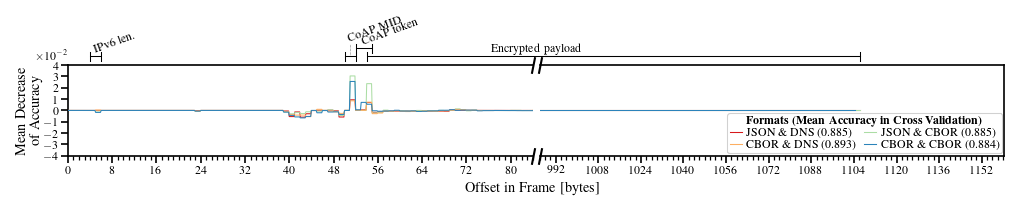

### Random Forest: “Ethernet”, D2, Blocksize: 1024

#### HTTPS

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_https_eth_1024.pdf) ($x$ max: 9191)

<Figure size 805.516x156.881 with 0 Axes>

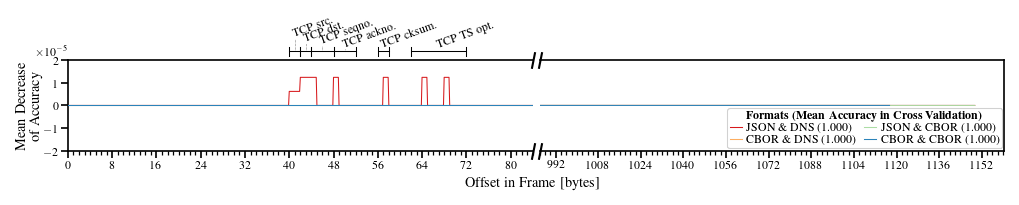

#### CoAP

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_coap_eth_1024.pdf) ($x$ max: 8719)

<Figure size 805.516x156.881 with 0 Axes>

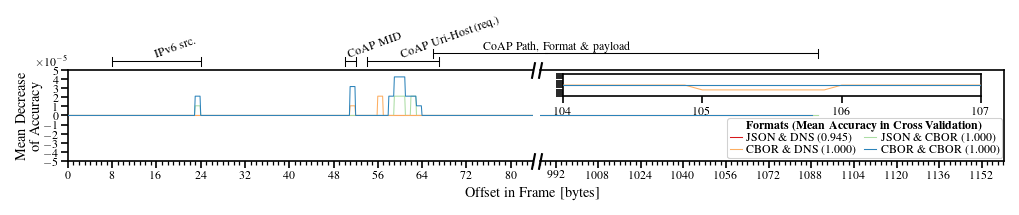

#### CoAPS

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_coaps_eth_1024.pdf) ($x$ max: 8951)

<Figure size 805.516x156.881 with 0 Axes>

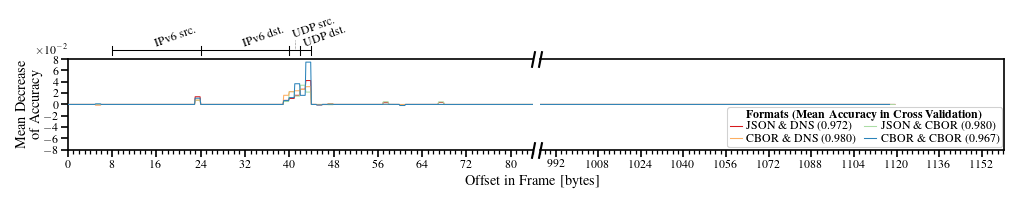

#### Onion OSCORE

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_oscore_eth_1024.pdf) ($x$ max: 8839)

<Figure size 805.516x156.881 with 0 Axes>

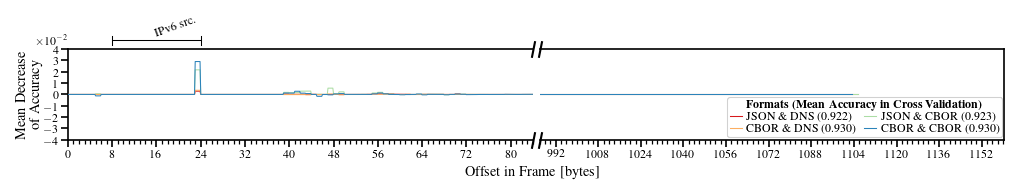

#### OSCORE

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_oscore-base_eth_1024.pdf) ($x$ max: 8839)

<Figure size 805.516x156.881 with 0 Axes>

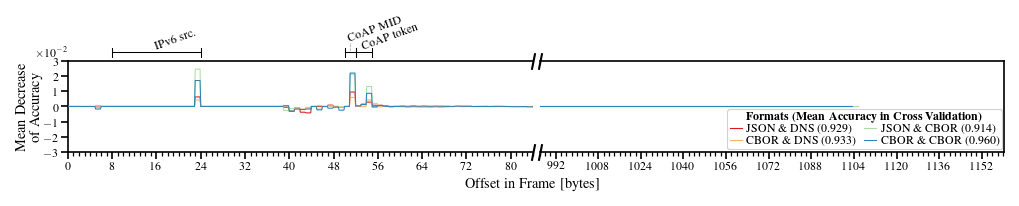

### Random Forest: “Ethernet”, P1, Blocksize: 1024

#### HTTPS

##### [Detail, P1, Block Size: 1024](plots/perm_imp_binvec_rf_p1_https_eth_1024.pdf) ($x$ max: 9191)

<Figure size 805.516x156.881 with 0 Axes>

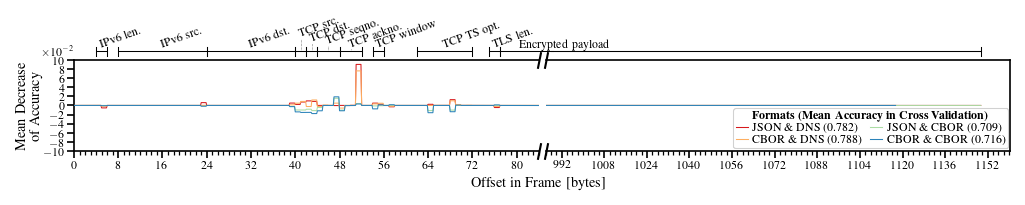

#### CoAP

##### [Detail, P1, Block Size: 1024](plots/perm_imp_binvec_rf_p1_coap_eth_1024.pdf) ($x$ max: 8767)

<Figure size 805.516x156.881 with 0 Axes>

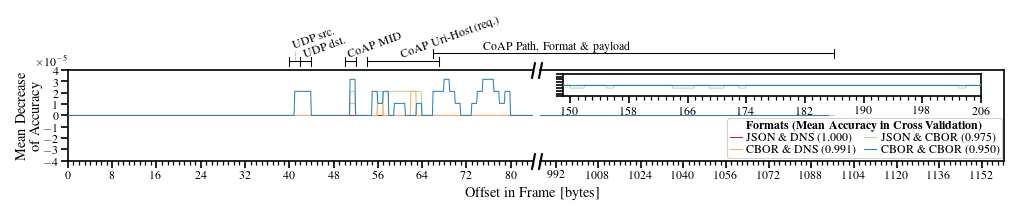

#### CoAPS

##### [Detail, P1, Block Size: 1024](plots/perm_imp_binvec_rf_p1_coaps_eth_1024.pdf) ($x$ max: 9007)

<Figure size 805.516x156.881 with 0 Axes>

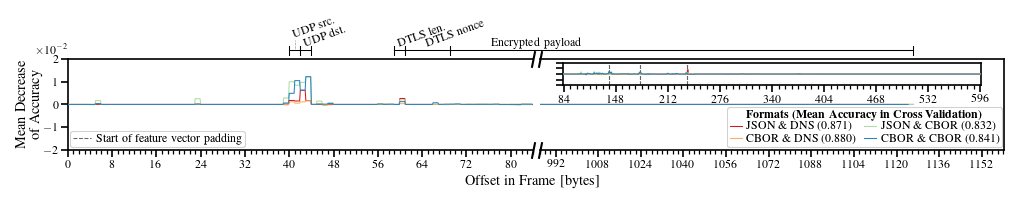

#### Onion OSCORE

##### [Detail, P1, Block Size: 1024](plots/perm_imp_binvec_rf_p1_oscore_eth_1024.pdf) ($x$ max: 9007)

<Figure size 805.516x156.881 with 0 Axes>

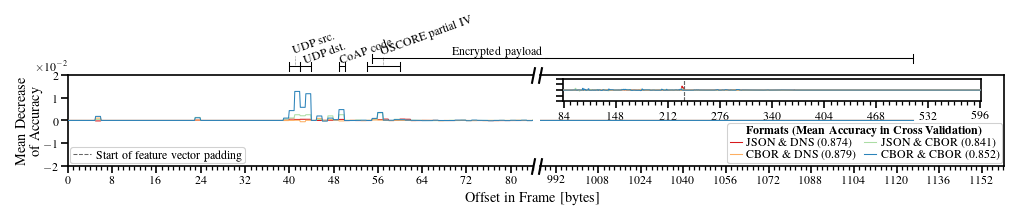

#### OSCORE

##### [Detail, P1, Block Size: 1024](plots/perm_imp_binvec_rf_p1_oscore-base_eth_1024.pdf) ($x$ max: 8895)

<Figure size 805.516x156.881 with 0 Axes>

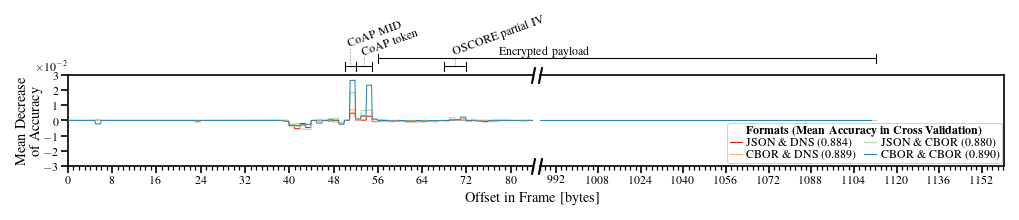

### Random Forest: “Ethernet”, P2, Blocksize: 1024

#### HTTPS

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_https_eth_1024.pdf) ($x$ max: 9191)

<Figure size 805.516x156.881 with 0 Axes>

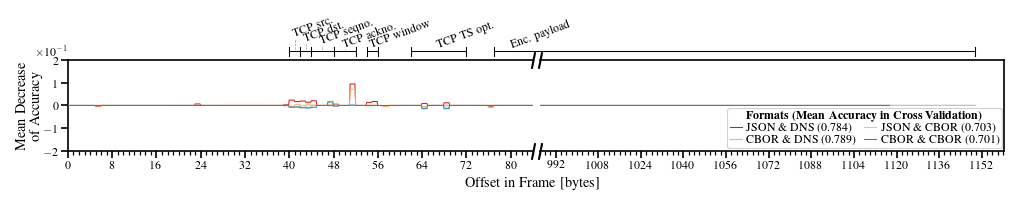

#### CoAP

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_coap_eth_1024.pdf) ($x$ max: 8767)

<Figure size 805.516x156.881 with 0 Axes>

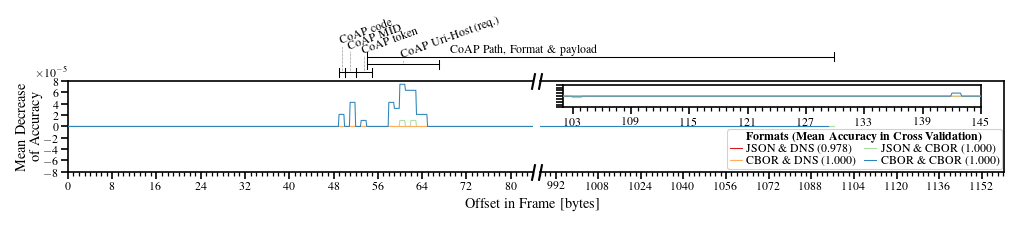

#### CoAPS

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_coaps_eth_1024.pdf) ($x$ max: 9007)

<Figure size 805.516x156.881 with 0 Axes>

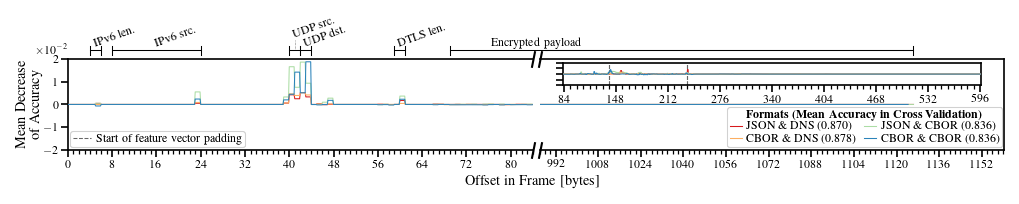

#### Onion OSCORE

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_oscore_eth_1024.pdf) ($x$ max: 8999)

<Figure size 805.516x156.881 with 0 Axes>

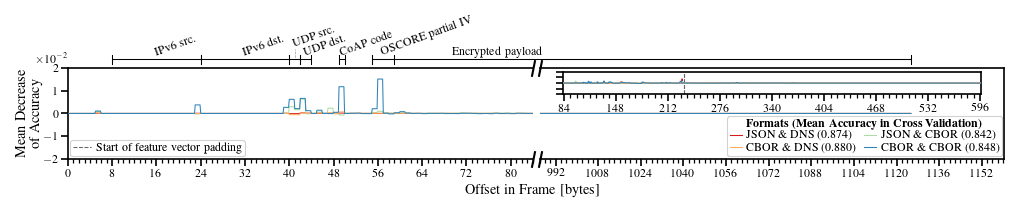

#### OSCORE

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_oscore-base_eth_1024.pdf) ($x$ max: 8887)

<Figure size 805.516x156.881 with 0 Axes>

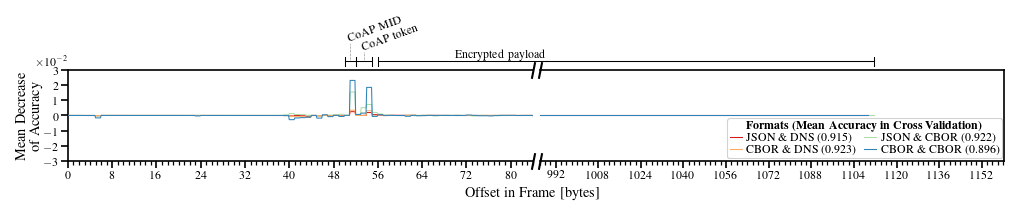

### Random Forest: “Ethernet”, D1, Blocksize: 64

#### CoAP

##### [Detail, D1, Block Size: 64](plots/perm_imp_binvec_rf_d1_coap_eth_64.pdf) ($x$ max: 5543)

<Figure size 805.516x156.881 with 0 Axes>

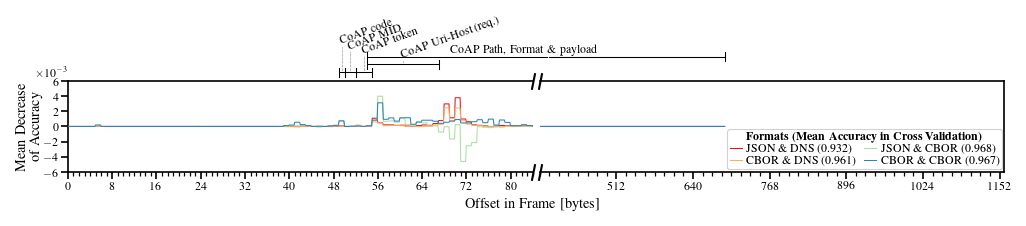

#### CoAPS

##### [Detail, D1, Block Size: 64](plots/perm_imp_binvec_rf_d1_coaps_eth_64.pdf) ($x$ max: 8967)

<Figure size 805.516x156.881 with 0 Axes>

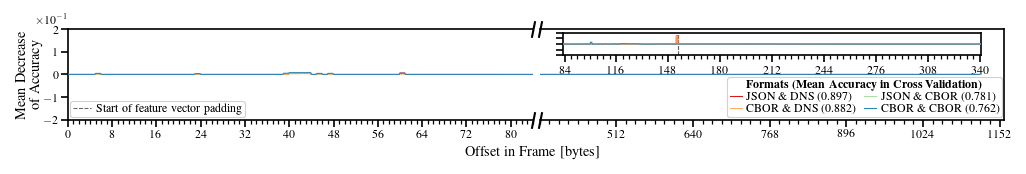

#### Onion OSCORE

##### [Detail, D1, Block Size: 64](plots/perm_imp_binvec_rf_d1_oscore_eth_64.pdf) ($x$ max: 5663)

<Figure size 805.516x156.881 with 0 Axes>

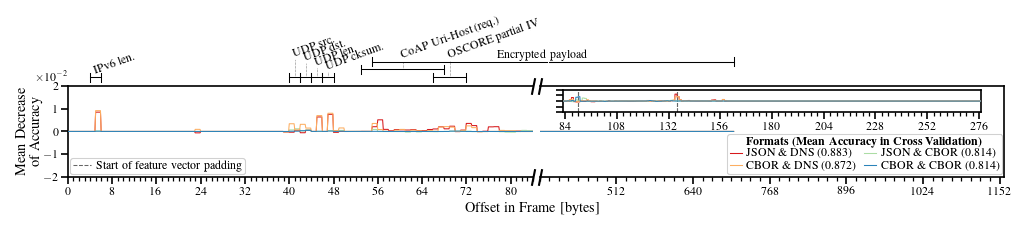

#### OSCORE

##### [Detail, D1, Block Size: 64](plots/perm_imp_binvec_rf_d1_oscore-base_eth_64.pdf) ($x$ max: 5671)

<Figure size 805.516x156.881 with 0 Axes>

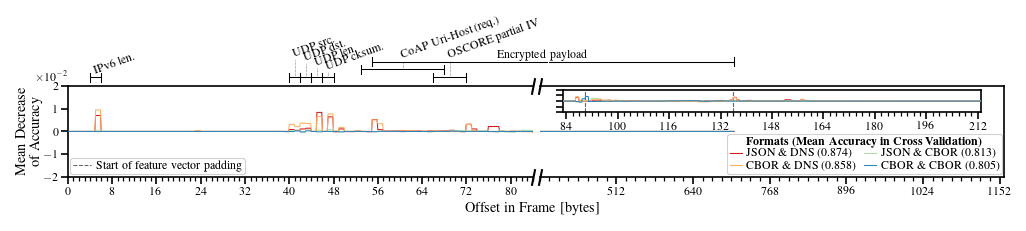

### Random Forest: “Ethernet”, D2, Blocksize: 64

#### CoAP

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_coap_eth_64.pdf) ($x$ max: 5543)

<Figure size 805.516x156.881 with 0 Axes>

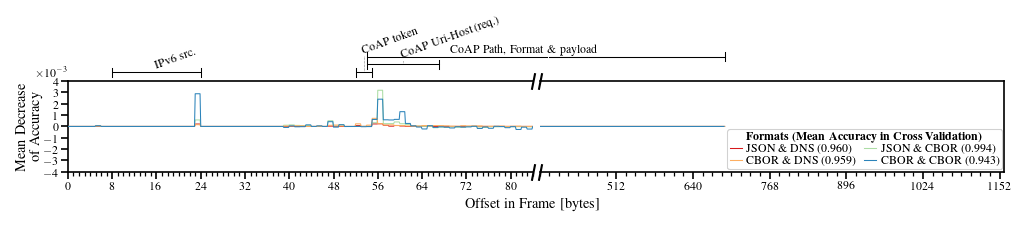

#### CoAPS

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_coaps_eth_64.pdf) ($x$ max: 8967)

<Figure size 805.516x156.881 with 0 Axes>

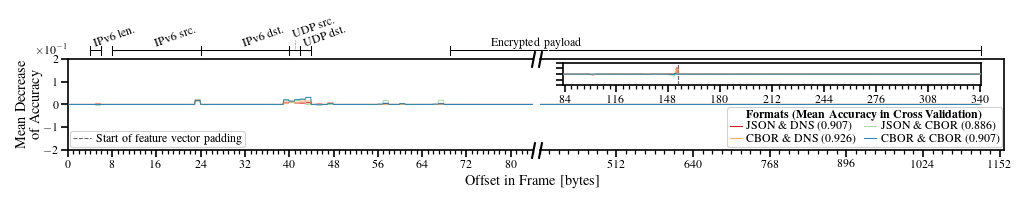

#### Onion OSCORE

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_oscore_eth_64.pdf) ($x$ max: 5663)

<Figure size 805.516x156.881 with 0 Axes>

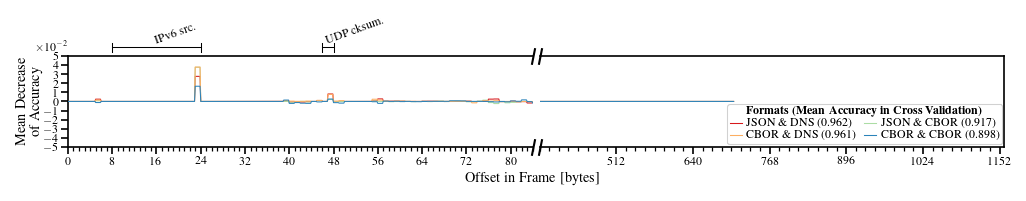

#### OSCORE

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_oscore-base_eth_64.pdf) ($x$ max: 5663)

<Figure size 805.516x156.881 with 0 Axes>

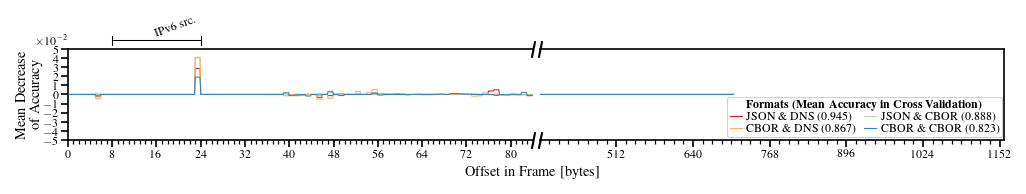

### Random Forest: “Ethernet”, P1, Blocksize: 64

#### CoAP

##### [Detail, P1, Block Size: 64](plots/perm_imp_binvec_rf_p1_coap_eth_64.pdf) ($x$ max: 8783)

<Figure size 805.516x156.881 with 0 Axes>

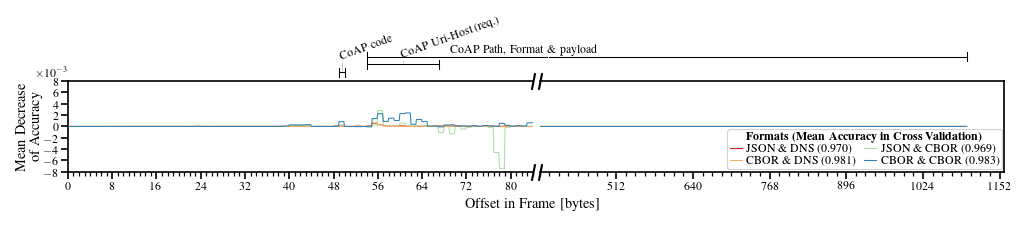

#### CoAPS

##### [Detail, P1, Block Size: 64](plots/perm_imp_binvec_rf_p1_coaps_eth_64.pdf) ($x$ max: 9023)

<Figure size 805.516x156.881 with 0 Axes>

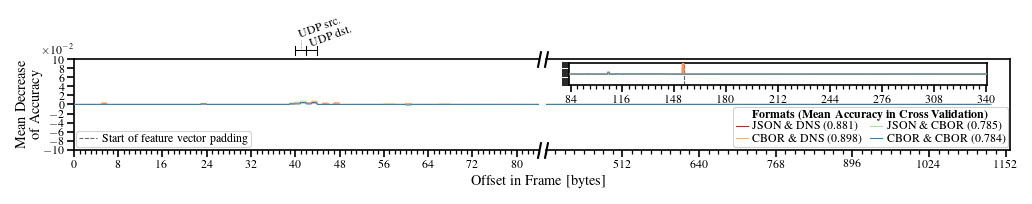

#### Onion OSCORE

##### [Detail, P1, Block Size: 64](plots/perm_imp_binvec_rf_p1_oscore_eth_64.pdf) ($x$ max: 5847)

<Figure size 805.516x156.881 with 0 Axes>

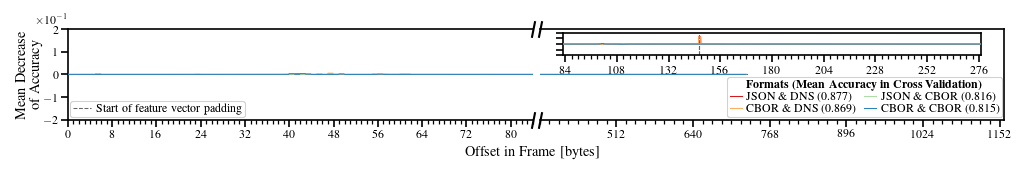

#### OSCORE

##### [Detail, P1, Block Size: 64](plots/perm_imp_binvec_rf_p1_oscore-base_eth_64.pdf) ($x$ max: 8911)

<Figure size 805.516x156.881 with 0 Axes>

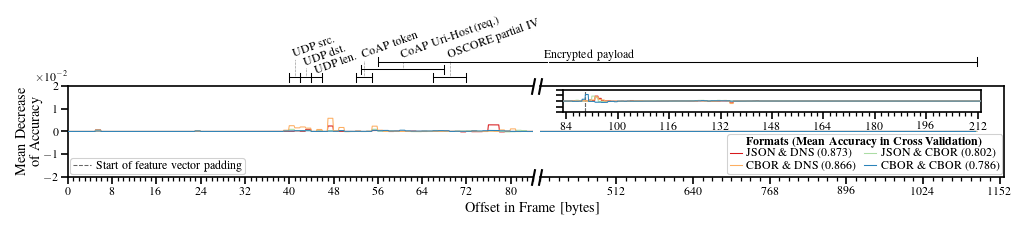

### Random Forest: “Ethernet”, P2, Blocksize: 64

#### CoAP

##### [Detail, P2, Block Size: 64](plots/perm_imp_binvec_rf_p2_coap_eth_64.pdf) ($x$ max: 8783)

<Figure size 805.516x156.881 with 0 Axes>

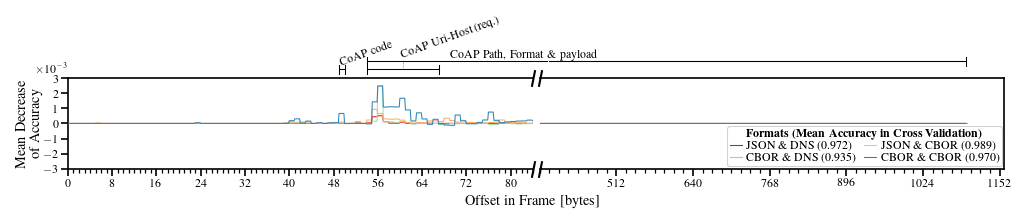

#### CoAPS

##### [Detail, P2, Block Size: 64](plots/perm_imp_binvec_rf_p2_coaps_eth_64.pdf) ($x$ max: 9023)

<Figure size 805.516x156.881 with 0 Axes>

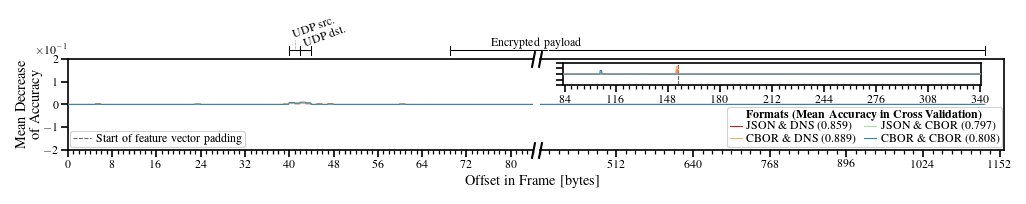

#### Onion OSCORE

##### [Detail, P2, Block Size: 64](plots/perm_imp_binvec_rf_p2_oscore_eth_64.pdf) ($x$ max: 5839)

<Figure size 805.516x156.881 with 0 Axes>

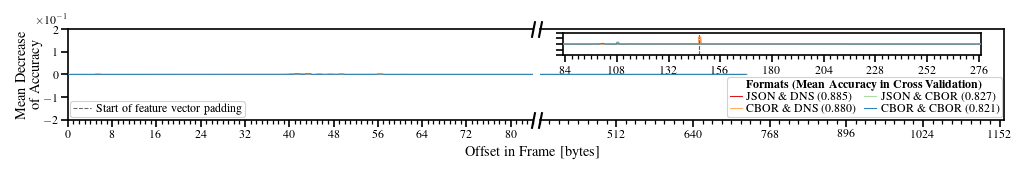

#### OSCORE

##### [Detail, P2, Block Size: 64](plots/perm_imp_binvec_rf_p2_oscore-base_eth_64.pdf) ($x$ max: 8911)

<Figure size 805.516x156.881 with 0 Axes>

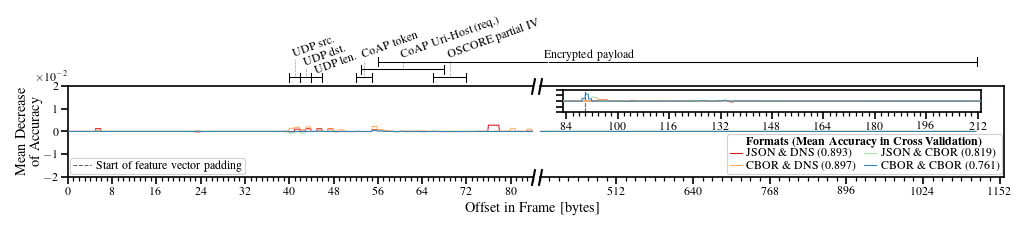

### Random Forest: SCHC, D1, Blocksize: 1024

#### CoAPS

##### [Detail, D1, Block Size: 1024](plots/perm_imp_binvec_rf_d1_coaps_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

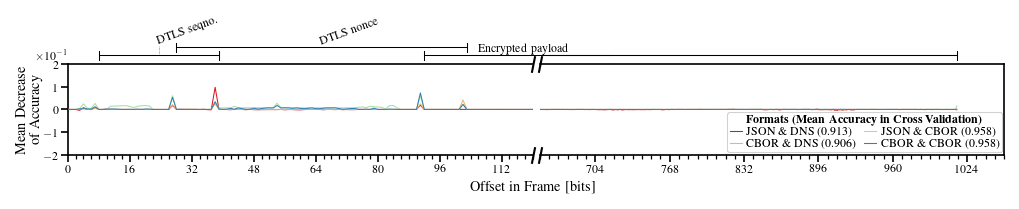

#### Onion OSCORE

##### [Detail, D1, Block Size: 1024](plots/perm_imp_binvec_rf_d1_oscore_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

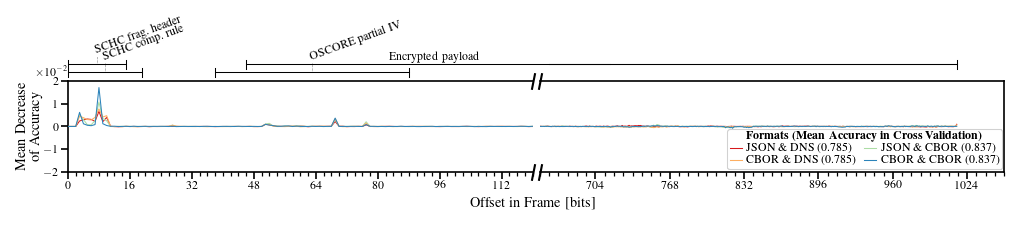

#### OSCORE

##### [Detail, D1, Block Size: 1024](plots/perm_imp_binvec_rf_d1_oscore-base_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

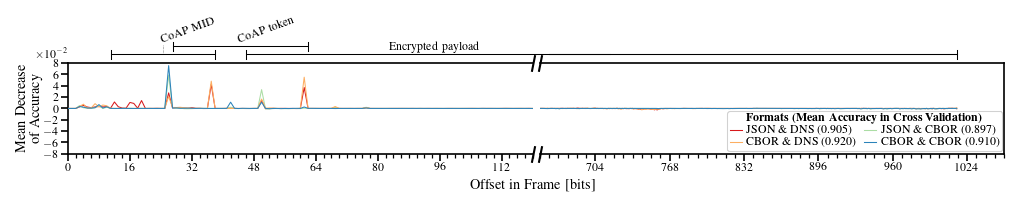

### Random Forest: SCHC, D2, Blocksize: 1024

#### CoAPS

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_coaps_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

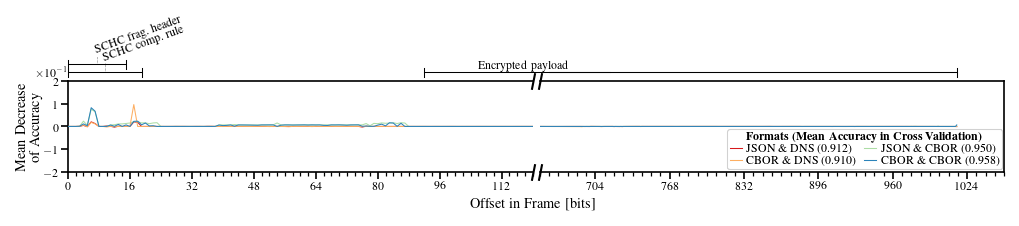

#### CoAPS (-min-rules)

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_coaps_schc-min-rules_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

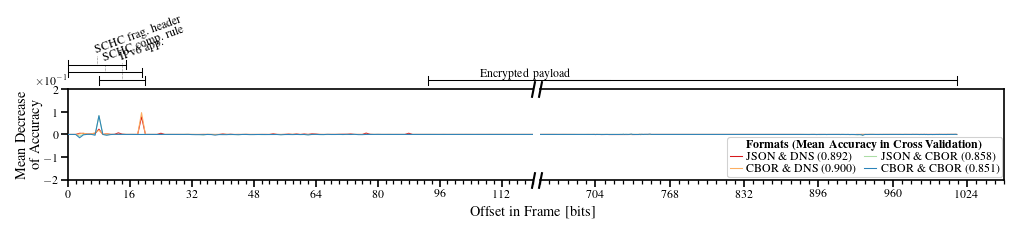

#### CoAPS (-peer-based)

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_coaps_schc-peer-based_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

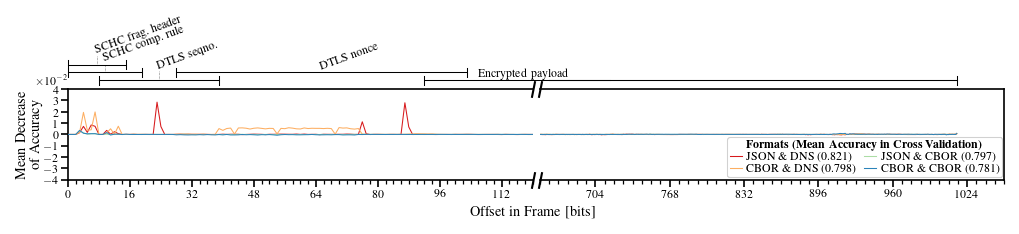

#### Onion OSCORE

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_oscore_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

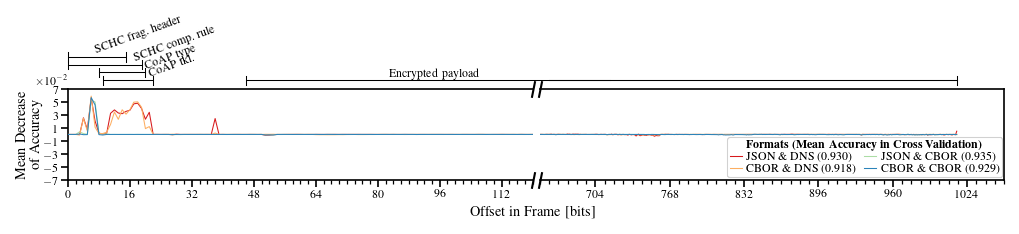

#### Onion OSCORE (-min-rules)

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_oscore_schc-min-rules_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

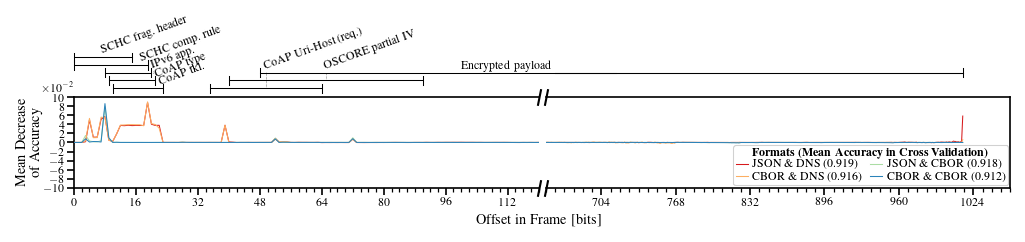

#### Onion OSCORE (-peer-based)

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_oscore_schc-peer-based_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

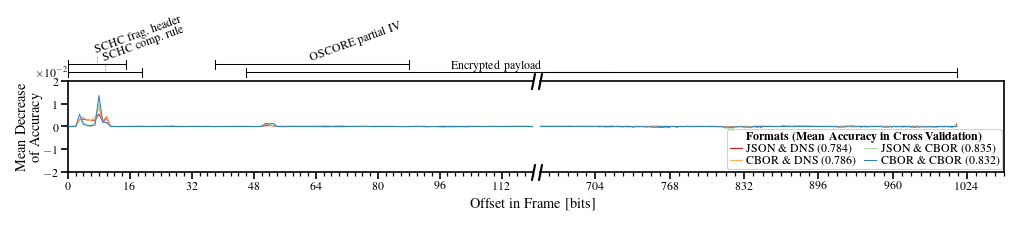

#### OSCORE

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_oscore-base_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

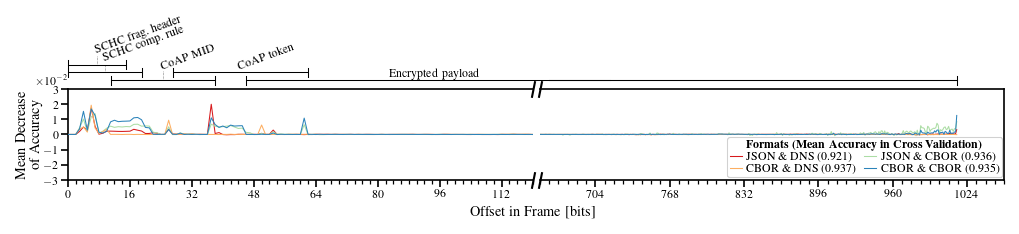

#### OSCORE (-min-rules)

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_oscore-base_schc-min-rules_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

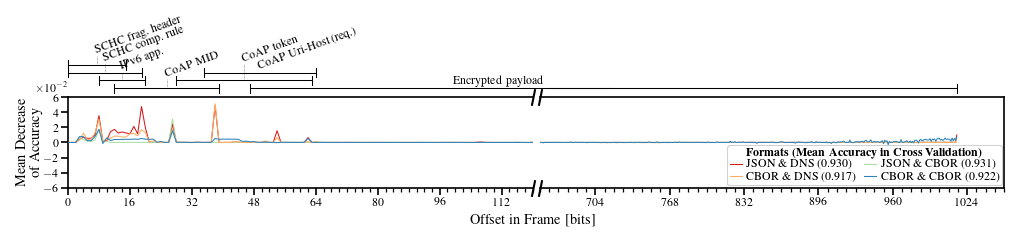

#### OSCORE (-peer-based)

##### [Detail, D2, Block Size: 1024](plots/perm_imp_binvec_rf_d2_oscore-base_schc-peer-based_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

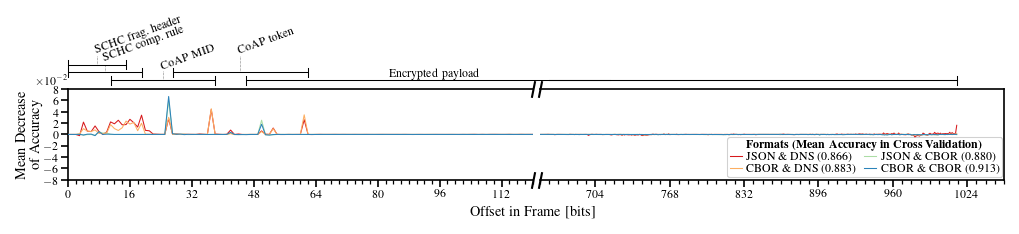

### Random Forest: SCHC, P1, Blocksize: 1024

#### CoAPS

##### [Detail, P1, Block Size: 1024](plots/perm_imp_binvec_rf_p1_coaps_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

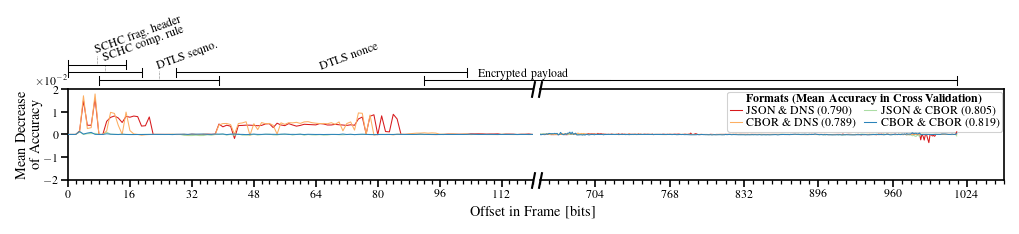

#### Onion OSCORE

##### [Detail, P1, Block Size: 1024](plots/perm_imp_binvec_rf_p1_oscore_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

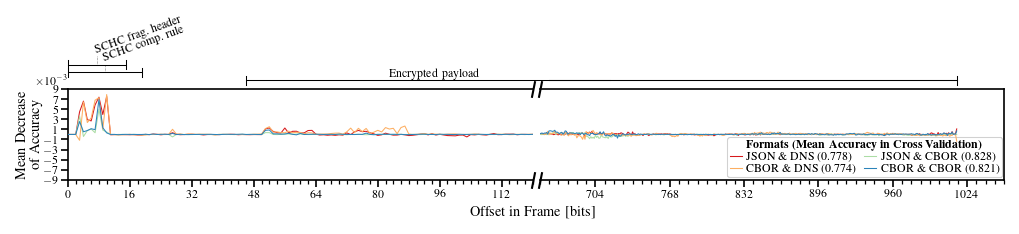

#### OSCORE

##### [Detail, P1, Block Size: 1024](plots/perm_imp_binvec_rf_p1_oscore-base_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

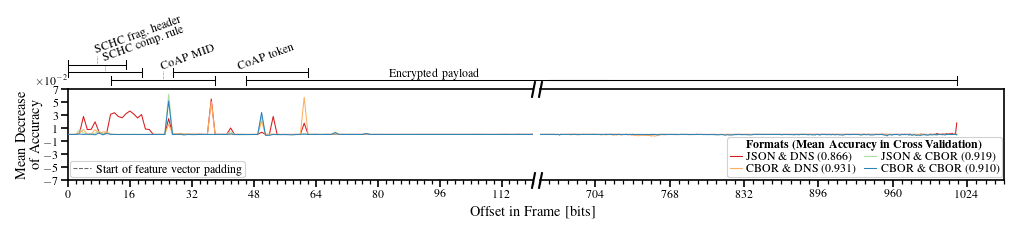

### Random Forest: SCHC, P2, Blocksize: 1024

#### CoAPS

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_coaps_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

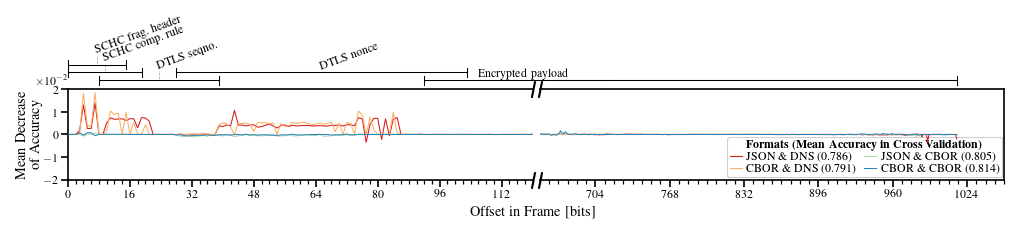

#### Onion OSCORE

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_oscore_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

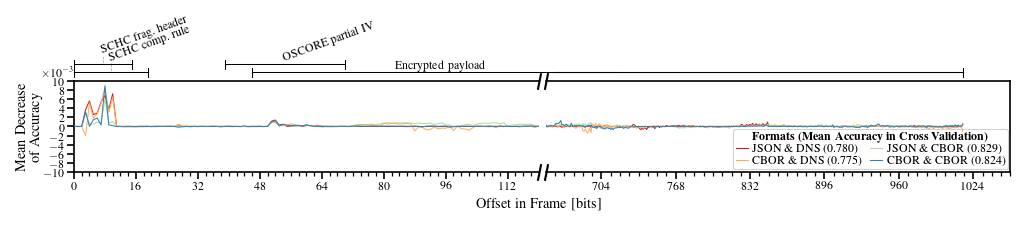

#### OSCORE

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_oscore-base_schc_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

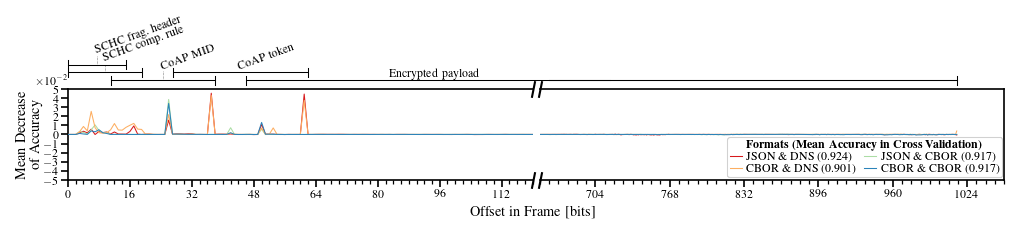

#### OSCORE (-min-rules)

##### [Detail, P2, Block Size: 1024](plots/perm_imp_binvec_rf_p2_oscore-base_schc-min-rules_1024.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

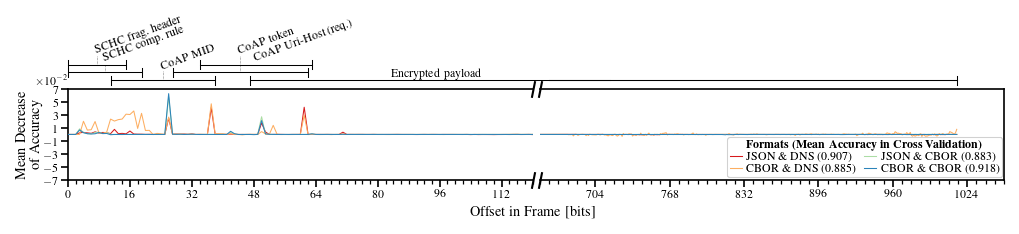

### Random Forest: SCHC, D1, Blocksize: 64

#### CoAPS

##### [Detail, D1, Block Size: 64](plots/perm_imp_binvec_rf_d1_coaps_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

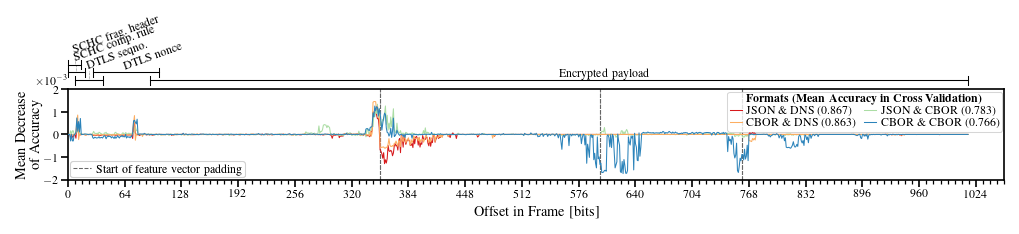

#### Onion OSCORE

##### [Detail, D1, Block Size: 64](plots/perm_imp_binvec_rf_d1_oscore_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

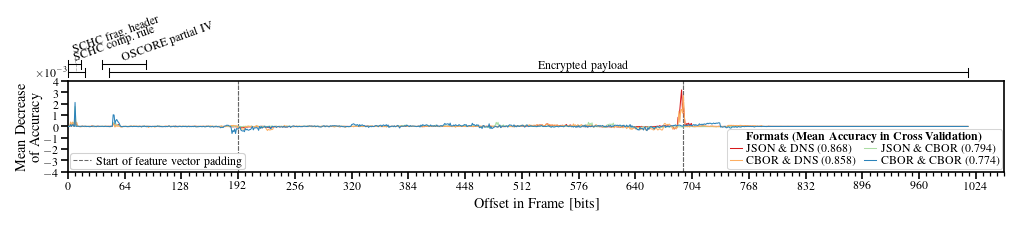

#### OSCORE

##### [Detail, D1, Block Size: 64](plots/perm_imp_binvec_rf_d1_oscore-base_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

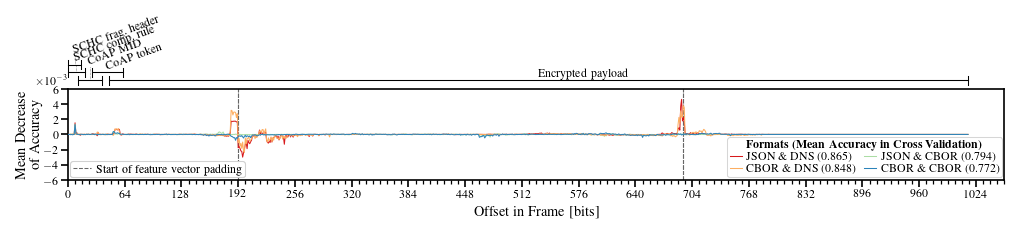

### Random Forest: SCHC, D2, Blocksize: 64

#### CoAPS

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_coaps_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

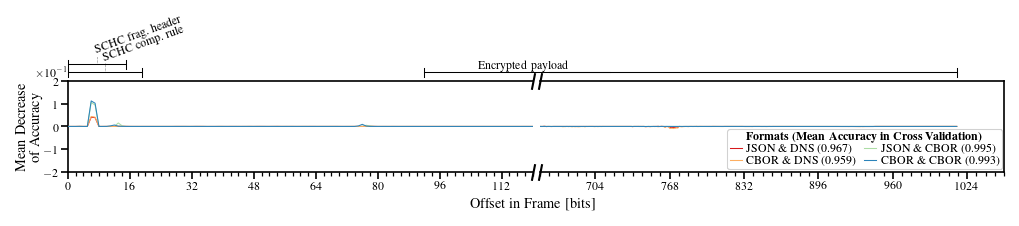

#### CoAPS (-min-rules)

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_coaps_schc-min-rules_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

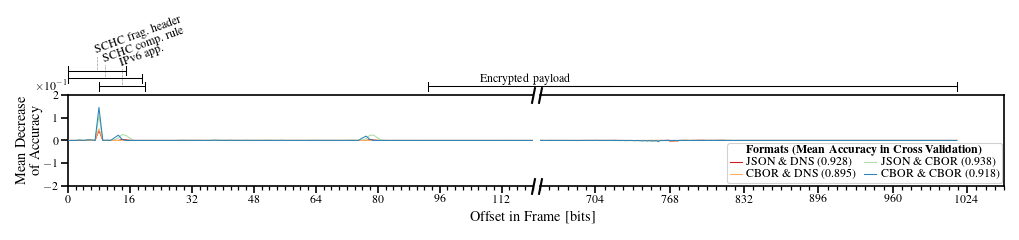

#### CoAPS (-peer-based)

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_coaps_schc-peer-based_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

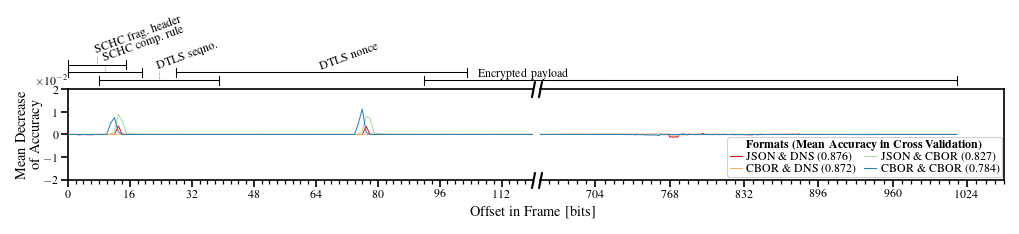

#### Onion OSCORE

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_oscore_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

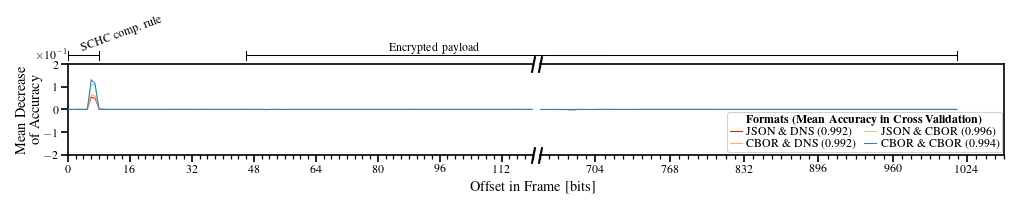

#### Onion OSCORE (-min-rules)

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_oscore_schc-min-rules_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

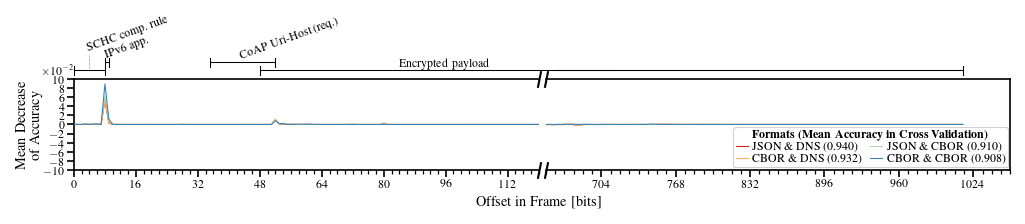

#### Onion OSCORE (-peer-based)

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_oscore_schc-peer-based_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

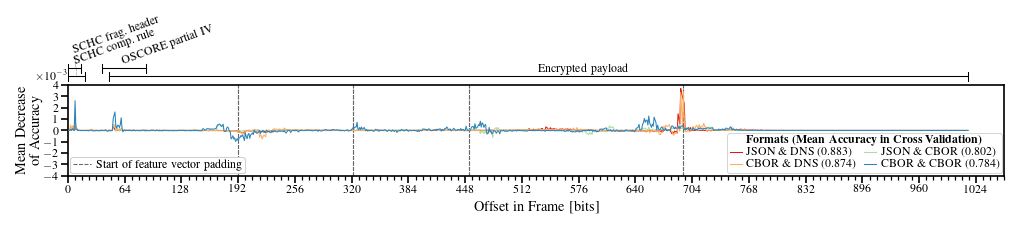

#### OSCORE

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_oscore-base_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

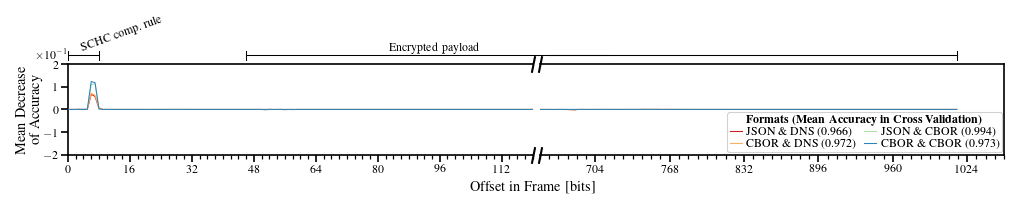

#### OSCORE (-min-rules)

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_oscore-base_schc-min-rules_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

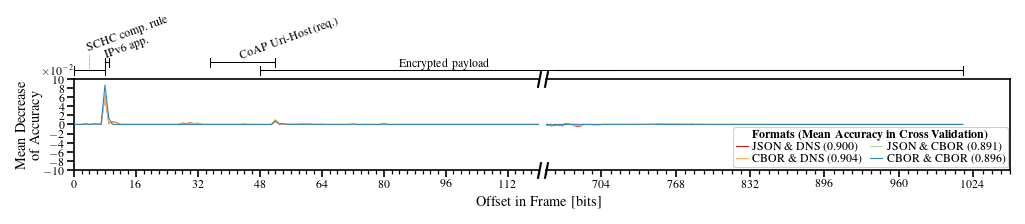

#### OSCORE (-peer-based)

##### [Detail, D2, Block Size: 64](plots/perm_imp_binvec_rf_d2_oscore-base_schc-peer-based_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

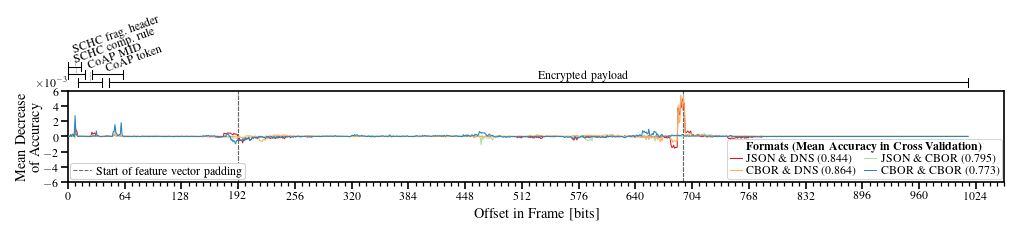

### Random Forest: SCHC, P1, Blocksize: 64

#### CoAPS

##### [Detail, P1, Block Size: 64](plots/perm_imp_binvec_rf_p1_coaps_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

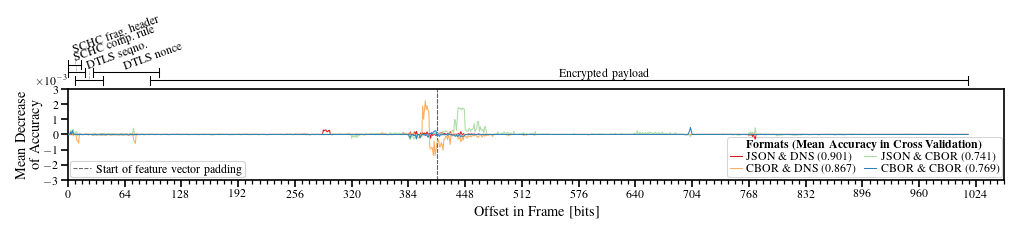

#### Onion OSCORE

##### [Detail, P1, Block Size: 64](plots/perm_imp_binvec_rf_p1_oscore_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

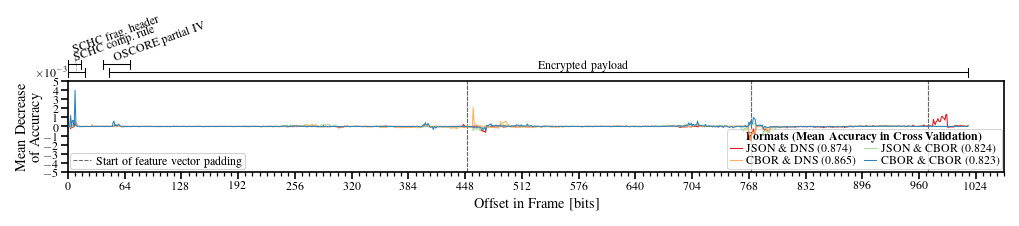

#### OSCORE

##### [Detail, P1, Block Size: 64](plots/perm_imp_binvec_rf_p1_oscore-base_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

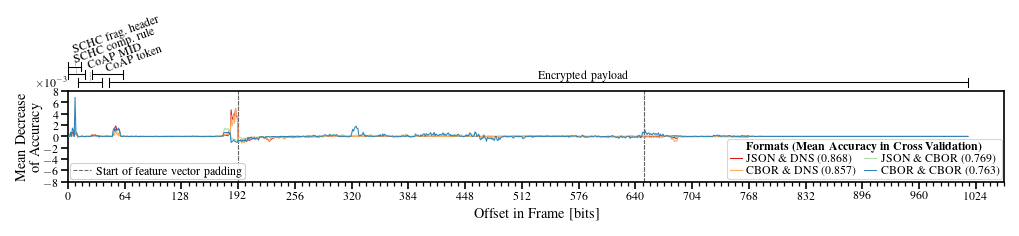

### Random Forest: SCHC, P2, Blocksize: 64

#### CoAPS

##### [Detail, P2, Block Size: 64](plots/perm_imp_binvec_rf_p2_coaps_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

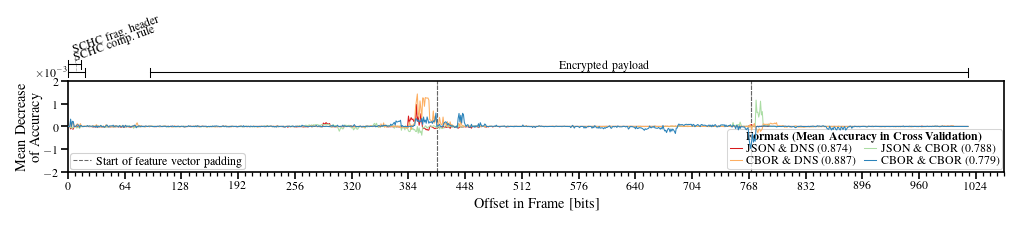

#### Onion OSCORE

##### [Detail, P2, Block Size: 64](plots/perm_imp_binvec_rf_p2_oscore_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

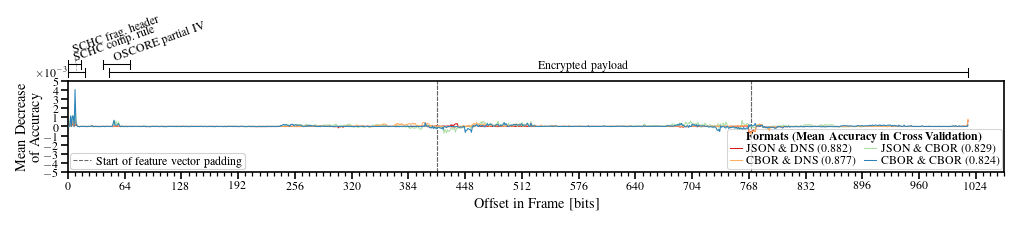

#### OSCORE

##### [Detail, P2, Block Size: 64](plots/perm_imp_binvec_rf_p2_oscore-base_schc_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

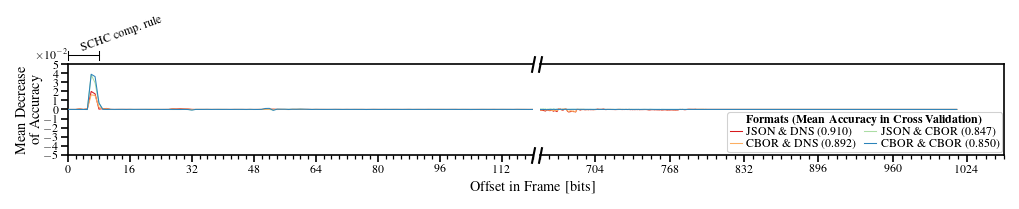

#### OSCORE (-min-rules)

##### [Detail, P2, Block Size: 64](plots/perm_imp_binvec_rf_p2_oscore-base_schc-min-rules_64.pdf) ($x$ max: 1015)

<Figure size 805.516x156.881 with 0 Axes>

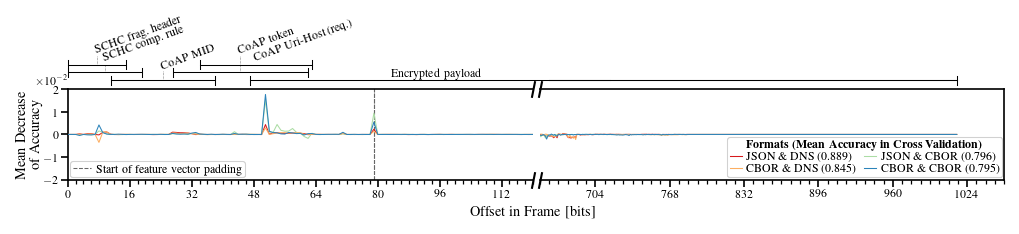

In [24]:
matplotlib.style.use("mlenders_fullwidth.mplstyle")

matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.19,
    matplotlib.rcParams["figure.figsize"][1] * 0.75,
)
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    ['#d7191c','#fdae61','#abdda4','#2b83ba'],
    #matplotlib.colormaps["Dark2"].colors,
)
matplotlib.rcParams["hatch.linewidth"] = 2
matplotlib.rcParams["lines.linewidth"] = 0.5
matplotlib.rcParams["lines.markersize"] = 2.5
matplotlib.rcParams["legend.fontsize"] = "xx-small"
#matplotlib.rcParams["legend.labelspacing"] = 0.2
matplotlib.rcParams["legend.title_fontsize"] = "xx-small"
matplotlib.rcParams["ytick.minor.width"] = 0.3

CLASSIFIERS = [
    #"dt",
    #"lr",
    #"knn",
    #"svm",
    "rf"
]
CLASSIFIER_READABLE = {
    "nb": "Naïve Bayes",
    "lr": "Logistic Regression",
    "knn": "K-Nearest Neighbors",
    "svm": "Support Vector Machine",
    "dt": "Decision Tree",
    "rf": "Random Forest",
}
METRICS_VARIABLE = {
    "accuracy": "A",
    "f1": "F_1",
}
XMAX = {
    ("", ""): 9280,
    ("", "_b64"): 9280,
    ("-schc", ""): 1056,
    ("-schc", "_b64"): 1056,
}
XBREAK = {
    ("", ""): (672, 7900),
    ("", "_b64"): (672, 3200),
    ("-schc", ""): (120, 664),
    ("-schc", "_b64"): (120, 664),
}
XLABEL = {"": "Offset in Frame [bytes]", "-schc": "Offset in Frame [bits]"}

XTICKS1 = {
    ("", "", "https"): numpy.arange(0, XBREAK["", ""][0] + 8, 8 * 8),
    ("", "", "coap"): numpy.arange(0, XBREAK["", ""][0] + 8, 8 * 8),
    ("", "", "coaps"): numpy.arange(0, XBREAK["", ""][0] + 8, 8 * 8),
    ("", "", "oscore-base"): numpy.arange(0, XBREAK["", ""][0] + 8, 8 * 8),
    ("", "", "oscore"): numpy.arange(0, XBREAK["", ""][0] + 8, 8 * 8),
    ("", "_b64", "https"): numpy.arange(0, XBREAK["", "_b64"][0] + 8, 8 * 8),
    ("", "_b64", "coap"): numpy.arange(0, XBREAK["", "_b64"][0] + 8, 8 * 8),
    ("", "_b64", "coaps"): numpy.arange(0, XBREAK["", "_b64"][0] + 8, 8 * 8),
    ("", "_b64", "oscore-base"): numpy.arange(0, XBREAK["", "_b64"][0] + 8, 8 * 8),
    ("", "_b64", "oscore"): numpy.arange(0, XBREAK["", "_b64"][0] + 8, 8 * 8),
    ("-schc", "", "https"): numpy.arange(0, XBREAK["-schc", ""][0] + 8, 16),
    ("-schc", "", "coap"): numpy.arange(0, XBREAK["-schc", ""][0] + 8, 16),
    ("-schc", "", "coaps"): numpy.arange(0, XBREAK["-schc", ""][0] + 8, 16),
    ("-schc", "", "oscore-base"): numpy.arange(0, XBREAK["-schc", ""][0] + 8, 16),
    ("-schc", "", "oscore"): numpy.arange(0, XBREAK["-schc", ""][0] + 8, 16),
    ("-schc", "_b64", "https"): numpy.arange(0, XBREAK["-schc", "_b64"][0] + 8, 16),
    ("-schc", "_b64", "coap"): numpy.arange(0, XBREAK["-schc", "_b64"][0] + 8, 16),
    ("-schc", "_b64", "coaps"): numpy.arange(0, XBREAK["-schc", "_b64"][0] + 8, 16),
    ("-schc", "_b64", "oscore-base"): numpy.arange(0, XBREAK["-schc", "_b64"][0] + 8, 16),
    ("-schc", "_b64", "oscore"): numpy.arange(0, XBREAK["-schc", "_b64"][0] + 8, 16),
}
XTICKS2 = {
    ("", "", "https"): numpy.arange(XBREAK["", ""][1] + 4 * 8, XMAX["", ""] + 8, 16 * 8),
    ("", "", "coap"): numpy.arange(XBREAK["", ""][1] + 4 * 8, XMAX["", ""] + 8, 16 * 8),
    ("", "", "coaps"): numpy.arange(XBREAK["", ""][1] + 4 * 8, XMAX["", ""] + 8, 16 * 8),
    ("", "", "oscore-base"): numpy.arange(XBREAK["", ""][1] + 4 * 8, XMAX["", ""] + 8, 16 * 8),
    ("", "", "oscore"): numpy.arange(XBREAK["", ""][1] + 4 * 8, XMAX["", ""] + 8, 16 * 8),
    ("", "_b64", "https"): numpy.arange(XBREAK["", "_b64"][1] + 112 * 8, XMAX["", "_b64"] + 8, 128 * 8),
    ("", "_b64", "coap"): numpy.arange(XBREAK["", "_b64"][1] + 112 * 8, XMAX["", "_b64"] + 8, 128 * 8),
    ("", "_b64", "coaps"): numpy.arange(XBREAK["", "_b64"][1] + 112 * 8, XMAX["", "_b64"] + 8, 128 * 8),
    ("", "_b64", "oscore-base"): numpy.arange(XBREAK["", "_b64"][1] + 112 * 8, XMAX["", "_b64"] + 8, 128 * 8),
    ("", "_b64", "oscore"): numpy.arange(XBREAK["", "_b64"][1] + 112 * 8, XMAX["", "_b64"] + 8, 128 * 8),
    ("-schc", "", "https"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "", "coap"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "", "coaps"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "", "oscore-base"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "", "oscore"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "_b64", "https"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "_b64", "coap"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "_b64", "coaps"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "_b64", "oscore-base"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
    ("-schc", "_b64", "oscore"): numpy.arange(XBREAK["-schc", ""][1] + 40, XMAX["-schc", ""] + 8, 64),
}
XFORMATTER = {"": lambda x, pos: f"${x / 8:.0f}$", "-schc": lambda x, pos: f"${x:.0f}$"}

XTICKS0 = {
    ("rf", "-schc", "", "_b64", "coaps", "d1"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "-min-rules", "_b64", "coaps", "d2"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "-peer-based", "_b64", "coaps", "d2"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "coaps", "p1"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "coaps", "p2"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "oscore", "d1"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "oscore-base", "d1"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "-peer-based", "_b64", "oscore", "d2"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "oscore", "p1"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "oscore", "p2"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "oscore", "d1"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "-peer-based", "_b64", "oscore-base", "d2"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "oscore-base", "p1"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
    ("rf", "-schc", "", "_b64", "oscore-base", "p2"): numpy.arange(0, XMAX["-schc", "_b64"] + 8, 64),
}

XANNOTATIONS = {
    ("rf", "", "", "", "https", "d1"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "TCP src.", "ytextoffset": 2.5},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "TCP dst.", "ytextoffset": 1.5},
        {"xmin": 44 * 8, "xmax": 48 * 8, "fname": "TCP seqno.", "ytextoffset": 0.9},
        {"xmin": 48 * 8, "xmax": 52 * 8, "fname": "TCP ackno.", "ytextoffset": 0.2},
        {"xmin": 54 * 8, "xmax": 56 * 8, "fname": "TCP window"},
        #{"xmin": 56 * 8, "xmax": 58 * 8, "fname": "TCP cksum."},
        {"xmin": 62 * 8, "xmax": 72 * 8, "fname": "TCP TS opt."},
        {"xmin": 75 * 8, "xmax": 77 * 8, "fname": "TLS len."},
        {"xmin": 77 * 8, "xmax": 9191, "fname": "Encrypted payload", "xtextoffset": 36},
    ],
    ("rf", "", "", "", "coap", "d1"): [
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID", "ytextoffset": 2.5},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 54 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)"},
        {"xmin": 66 * 8, "xmax": 8719, "fname": r"CoAP Path, Format \& payload", "yoffset": 1.7, "ytextoffset": 1.7},
    ],
    ("rf", "", "", "", "coaps", "d1"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        {"xmin": 53 * 8, "xmax": 59 * 8, "fname": "DTLS seqno.", "ytextoffset": 1},
        {"xmin": 59 * 8, "xmax": 61 * 8, "fname": "DTLS len."},
        {"xmin": 61 * 8, "xmax": 69 * 8, "fname": "DTLS nonce"},
        {"xmin": 69 * 8, "xmax": 8951, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "", "oscore", "d1"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 3.8},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst.", "ytextoffset": 2.8},
        {"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len.", "ytextoffset": 1.8},
        {"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum.", "ytextoffset": 0.9},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token"},
        #{"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)"},
        #{"xmin": 67 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV"},
        {"xmin": 55 * 8, "xmax": 8847, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "", "oscore-base", "d1"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID", "ytextoffset": 2.5},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)"},
        #{"xmin": 67 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV", "ytextoffset": 1},
        {"xmin": 54 * 8, "xmax": 8847, "fname": "Encrypted payload", "xtextoffset": 60},
    ],
    ("rf", "", "", "", "https", "d2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "TCP src.", "ytextoffset": 2.5},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "TCP dst.", "ytextoffset": 1.5},
        {"xmin": 44 * 8, "xmax": 48 * 8, "fname": "TCP seqno.", "ytextoffset": 0.9},
        {"xmin": 48 * 8, "xmax": 52 * 8, "fname": "TCP ackno.", "ytextoffset": 0.2},
        #{"xmin": 54 * 8, "xmax": 56 * 8, "fname": "TCP window"},
        {"xmin": 56 * 8, "xmax": 58 * 8, "fname": "TCP cksum."},
        {"xmin": 62 * 8, "xmax": 72 * 8, "fname": "TCP TS opt."},
        #{"xmin": 75 * 8, "xmax": 77 * 8, "fname": "TLS len."},
        #{"xmin": 77 * 8, "xmax": 9191, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "", "coap", "d2"): [
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID"},
        {"xmin": 54 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)"},
        {"xmin": 66 * 8, "xmax": 8719, "fname": r"CoAP Path, Format \& payload", "yoffset": 1.7, "ytextoffset": 1.7},
    ],
    ("rf", "", "", "", "coaps", "d2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len.", "ytextoffset": 1.8},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum.", "ytextoffset": 0.9},
        #{"xmin": 53 * 8, "xmax": 59 * 8, "fname": "DTLS seqno."},
        #{"xmin": 59 * 8, "xmax": 61 * 8, "fname": "DTLS len."},
        #{"xmin": 61 * 8, "xmax": 69 * 8, "fname": "DTLS nonce"},
        #{"xmin": 69 * 8, "xmax": 8951, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "", "oscore", "d2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)"},
        #{"xmin": 55 * 8, "xmax": 8839, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "", "oscore-base", "d2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.8},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst.", "ytextoffset": 1.7},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token"},
        #{"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)"},
        #{"xmin": 66 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV"},
        #{"xmin": 55 * 8, "xmax": 8839, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "", "https", "p1"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "TCP src.", "ytextoffset": 2.5},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "TCP dst.", "ytextoffset": 1.5},
        {"xmin": 44 * 8, "xmax": 48 * 8, "fname": "TCP seqno.", "ytextoffset": 0.9},
        {"xmin": 48 * 8, "xmax": 52 * 8, "fname": "TCP ackno.", "ytextoffset": 0.2},
        {"xmin": 54 * 8, "xmax": 56 * 8, "fname": "TCP window"},
        #{"xmin": 56 * 8, "xmax": 58 * 8, "fname": "TCP cksum."},
        {"xmin": 62 * 8, "xmax": 72 * 8, "fname": "TCP TS opt."},
        {"xmin": 75 * 8, "xmax": 77 * 8, "fname": "TLS len."},
        {"xmin": 77 * 8, "xmax": 9191, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "", "coap", "p1"): [
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID"},
        {"xmin": 54 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)"},
        {"xmin": 66 * 8, "xmax": 8767, "fname": r"CoAP Path, Format \& payload", "yoffset": 1.7, "ytextoffset": 1.7},
    ],
    ("rf", "", "", "", "coaps", "p1"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 53 * 8, "xmax": 59 * 8, "fname": "DTLS seqno."},
        {"xmin": 59 * 8, "xmax": 61 * 8, "fname": "DTLS len."},
        {"xmin": 61 * 8, "xmax": 69 * 8, "fname": "DTLS nonce"},
        {"xmin": 69 * 8, "xmax": 9007, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "", "oscore", "p1"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        {"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        {"xmin": 54 * 8, "xmax": 60 * 8, "fname": "OSCORE partial IV", "ytextoffset": 1.7},
        {"xmin": 55 * 8, "xmax": 9007, "fname": "Encrypted payload", "yoffset": 1.7, "ytextoffset": 1.7},
    ],
    ("rf", "", "", "", "oscore-base", "p1"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID", "ytextoffset": 3.7},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "ytextoffset": 1.7},
        #{"xmin": 55 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)"},
        {"xmin": 68 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV", "ytextoffset": 1.7},
        {"xmin": 56 * 8, "xmax": 8895, "fname": "Encrypted payload", "xtextoffset": 8 * 8, "yoffset": 1.7, "ytextoffset": 1.7},
    ],
    ("rf", "", "", "", "https", "p2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "TCP src.", "ytextoffset": 2.5},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "TCP dst.", "ytextoffset": 1.5},
        {"xmin": 44 * 8, "xmax": 48 * 8, "fname": "TCP seqno.", "ytextoffset": 0.9},
        {"xmin": 48 * 8, "xmax": 52 * 8, "fname": "TCP ackno.", "ytextoffset": 0.2},
        {"xmin": 54 * 8, "xmax": 56 * 8, "fname": "TCP window"},
        #{"xmin": 56 * 8, "xmax": 58 * 8, "fname": "TCP cksum."},
        {"xmin": 62 * 8, "xmax": 72 * 8, "fname": "TCP TS opt."},
        #{"xmin": 75 * 8, "xmax": 77 * 8, "fname": "TLS len."},
        {"xmin": 77 * 8, "xmax": 9191, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "", "coap", "p2"): [
        {"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code", "ytextoffset": 5.5},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID", "ytextoffset": 4.3},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "ytextoffset": 3.4},
        {"xmin": 54 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 2.4},
        {"xmin": 54 * 8, "xmax": 8767, "fname": r"CoAP Path, Format \& payload", "yoffset": 3.4, "ytextoffset": 3.4},
    ],
    ("rf", "", "", "", "coaps", "p2"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 53 * 8, "xmax": 59 * 8, "fname": "DTLS seqno."},
        {"xmin": 59 * 8, "xmax": 61 * 8, "fname": "DTLS len."},
        #{"xmin": 61 * 8, "xmax": 69 * 8, "fname": "DTLS nonce"},
        {"xmin": 69 * 8, "xmax": 9007, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "", "oscore", "p2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        {"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        {"xmin": 55 * 8, "xmax": 59 * 8, "fname": "OSCORE partial IV"},
        {"xmin": 55 * 8, "xmax": 8999, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "", "oscore-base", "p2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID", "ytextoffset": 3.7},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "ytextoffset": 1.7},
        #{"xmin": 54 * 8, "xmax": 66 * 8, "fname": "CoAP Uri-Host (req.)"},
        #{"xmin": 66 * 8, "xmax": 70 * 8, "fname": "OSCORE partial IV"},
        {"xmin": 56 * 8, "xmax": 8887, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "_b64", "coap", "d1"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        {"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code", "ytextoffset": 5.5},
        {"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID", "ytextoffset": 4.3},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "ytextoffset": 3.4},
        {"xmin": 54 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 2.4},
        {"xmin": 54 * 8, "xmax": 5543, "fname": r"CoAP Path, Format \& payload", "yoffset": 3.4, "ytextoffset": 3.4},
    ],
    ("rf", "", "", "_b64", "coaps", "d1"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 53 * 8, "xmax": 59 * 8, "fname": "DTLS seqno."},
        #{"xmin": 59 * 8, "xmax": 61 * 8, "fname": "DTLS len."},
        #{"xmin": 61 * 8, "xmax": 69 * 8, "fname": "DTLS nonce"},
        #{"xmin": 69 * 8, "xmax": 8967, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "_b64", "oscore", "d1"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 3.8},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst.", "ytextoffset": 2.8},
        {"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len.", "ytextoffset": 1.8},
        {"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum.", "ytextoffset": 0.9},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        {"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 66 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV", "ytextoffset": 3.4},
        {"xmin": 55 * 8, "xmax": 5663, "fname": "Encrypted payload", "xtextoffset": 8 * 8, "yoffset": 3.4, "ytextoffset": 3.4},
    ],
    ("rf", "", "", "_b64", "oscore-base", "d1"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 3.8},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst.", "ytextoffset": 2.8},
        {"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len.", "ytextoffset": 1.8},
        {"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum.", "ytextoffset": 0.9},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        {"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 66 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV", "ytextoffset": 3.4},
        {"xmin": 55 * 8, "xmax": 5671, "fname": "Encrypted payload", "xtextoffset": 8 * 8, "yoffset": 3.4, "ytextoffset": 3.4},
    ],
    ("rf", "", "", "_b64", "coap", "d2"): [
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP type"},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "ytextoffset": 3.4},
        {"xmin": 54 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 2.4},
        {"xmin": 54 * 8, "xmax": 5543, "fname": r"CoAP Path, Format \& payload", "yoffset": 3.4, "ytextoffset": 3.4},

    ],
    ("rf", "", "", "_b64", "coaps", "d2"): [
        {"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 53 * 8, "xmax": 59 * 8, "fname": "DTLS seqno."},
        #{"xmin": 59 * 8, "xmax": 61 * 8, "fname": "DTLS len."},
        #{"xmin": 61 * 8, "xmax": 69 * 8, "fname": "DTLS nonce"},
        {"xmin": 69 * 8, "xmax": 8967, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "_b64", "oscore", "d2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        {"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 55 * 8, "xmax": 5663, "fname": "Enc. payload"},
        #{"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)"},
        #{"xmin": 67 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV"},
    ],
    ("rf", "", "", "_b64", "oscore-base", "d2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        {"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID"},
        #{"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token"},
        #{"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)"},
        #{"xmin": 66 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV"},
        #{"xmin": 55 * 8, "xmax": 5663, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "_b64", "coap", "p1"): [
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        {"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code", "ytextoffset": 2.0},
        #{"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID"},
        #{"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "ytextoffset": 3.4},
        {"xmin": 54 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 2.4},
        {"xmin": 54 * 8, "xmax": 8783, "fname": r"CoAP Path, Format \& payload", "yoffset": 3.4, "ytextoffset": 3.4},
    ],
    ("rf", "", "", "_b64", "coaps", "p1"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 53 * 8, "xmax": 59 * 8, "fname": "DTLS seqno."},
        #{"xmin": 59 * 8, "xmax": 61 * 8, "fname": "DTLS len."},
        #{"xmin": 61 * 8, "xmax": 69 * 8, "fname": "DTLS nonce"},
        #{"xmin": 69 * 8, "xmax": 9023, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "_b64", "oscore", "p1"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 54 * 8, "xmax": 60 * 8, "fname": "OSCORE partial IV"},
        #{"xmin": 55 * 8, "xmax": 5847, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "_b64", "oscore-base", "p1"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 3.8},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst.", "ytextoffset": 1.7},
        {"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID"},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "ytextoffset": 3.4},
        {"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 66 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV", "ytextoffset": 3.4},
        {"xmin": 56 * 8, "xmax": 8911, "fname": "Encrypted payload", "xtextoffset": 16 * 8, "yoffset": 3.4, "ytextoffset": 3.4},
    ],
    ("rf", "", "", "_b64", "coap", "p2"): [
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        {"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID"},
        #{"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token"},
        {"xmin": 54 * 8, "xmax": 67 * 8, "fname": "CoAP Uri-Host (req.)", "ytextoffset": 1.7},
        {"xmin": 54 * 8, "xmax": 8767, "fname": r"CoAP Path, Format \& payload", "yoffset": 1.7, "ytextoffset": 1.7},
    ],
    ("rf", "", "", "_b64", "coaps", "p2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 2.0},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 53 * 8, "xmax": 59 * 8, "fname": "DTLS seqno."},
        #{"xmin": 59 * 8, "xmax": 61 * 8, "fname": "DTLS len."},
        #{"xmin": 61 * 8, "xmax": 69 * 8, "fname": "DTLS nonce"},
        {"xmin": 69 * 8, "xmax": 9023, "fname": "Encrypted payload"},
    ],
    ("rf", "", "", "_b64", "oscore", "p2"): [
        #{"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src."},
        #{"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst."},
        #{"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 46 * 8, "xmax": 48 * 8, "fname": "UDP cksum."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 55 * 8, "xmax": 59 * 8, "fname": "OSCORE partial IV"},
        #{"xmin": 55 * 8, "xmax": 5839, "fname": "Enc. payload"},
    ],
    ("rf", "", "", "_b64", "oscore-base", "p2"): [
        #{"xmin": 4 * 8, "xmax": 6 * 8, "fname": "IPv6 len."},
        #{"xmin": 8 * 8, "xmax": 24 * 8, "fname": "IPv6 src."},
        #{"xmin": 24 * 8, "xmax": 40 * 8, "fname": "IPv6 dst."},
        {"xmin": 40 * 8, "xmax": 42 * 8, "fname": "UDP src.", "ytextoffset": 3.8},
        {"xmin": 42 * 8, "xmax": 44 * 8, "fname": "UDP dst.", "ytextoffset": 1.7},
        {"xmin": 44 * 8, "xmax": 46 * 8, "fname": "UDP len."},
        #{"xmin": 49 * 8, "xmax": 50 * 8, "fname": "CoAP code"},
        #{"xmin": 50 * 8, "xmax": 52 * 8, "fname": "CoAP MID"},
        {"xmin": 52 * 8, "xmax": 55 * 8, "fname": "CoAP token", "ytextoffset": 3.4},
        {"xmin": 53 * 8, "xmax": 68 * 8, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 66 * 8, "xmax": 72 * 8, "fname": "OSCORE partial IV", "ytextoffset": 3.4},
        {"xmin": 56 * 8, "xmax": 8911, "fname": "Encrypted payload", "xtextoffset": 16 * 8, "yoffset": 3.4, "ytextoffset": 3.4},
    ],
    ("rf", "-schc", "", "", "coaps", "d1"): [
        #{"xmin": 0, "xmax": 15, "fname": "SCHC frag. header"},
        #{"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule"},
        {"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        {"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "coaps", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        #{"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        #{"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-min-rules", "", "coaps", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 8, "xmax": 20, "fname": "IPv6 app.", "ytextoffset": 3.6},
        #{"xmin": 9, "xmax": 40, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        #{"xmin": 29, "xmax": 104, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 93, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-peer-based", "", "coaps", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        {"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "coaps", "p1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        {"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "coaps", "p2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        {"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "oscore", "d1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.2},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        {"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV", "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload", "yoffset": 1.7, "ytextoffset": 1.7},
    ],
    ("rf", "-schc", "", "", "oscore", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 5.1, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 3.4, "xtextoffset": 8, "ytextoffset": 3.4},
        {"xmin": 8, "xmax": 20, "fname": "CoAP type", "yoffset": 1.7, "xtextoffset": 6.5, "ytextoffset": 1.7},
        {"xmin": 9, "xmax": 22, "fname": "CoAP tkl.", "xtextoffset": 6},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
       # {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-min-rules", "", "oscore", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 6.8, "ytextoffset": 6.8},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 5.1,  "xtextoffset": 8, "ytextoffset": 5.1},
        {"xmin": 8, "xmax": 20, "fname": "IPv6 app.", "yoffset": 3.4, "xtextoffset": 6.5, "ytextoffset": 3.6},
        {"xmin": 9, "xmax": 21, "fname": "CoAP type", "yoffset": 1.7, "xtextoffset": 6.5, "ytextoffset": 1.7},
        {"xmin": 10, "xmax": 23, "fname": "CoAP tkl.", "xtextoffset": 6},
        #{"xmin": 12, "xmax": 39, "fname": "CoAP MID"},
        #{"xmin": 28, "xmax": 63, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 35, "xmax": 64, "fname": "CoAP Uri-Host (req.)", "ytextoffset": 3.4},
        {"xmin": 40, "xmax": 90, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 48, "xmax": 1015, "fname": "Encrypted payload", "xtextoffset": 16, "yoffset": 3.4, "ytextoffset": 3.4},
    ],
    ("rf", "-schc", "-peer-based", "", "oscore", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        {"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload", "xtextoffset": 16},
    ],
    ("rf", "-schc", "", "", "oscore", "p1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        #{"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "oscore", "p2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID"},
        #{"xmin": 27, "xmax": 62, "fname": "CoAP token"},
        {"xmin": 39, "xmax": 70, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "oscore-base", "d1"): [
        #{"xmin": 0, "xmax": 15, "fname": "SCHC frag. header"},
        #{"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule"},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "oscore-base", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token",  "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-min-rules", "", "oscore-base", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 5.1, "ytextoffset": 6.8},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 8, "xmax": 20, "fname": "IPv6 app.", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 12, "xmax": 39, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 28, "xmax": 63, "fname": "CoAP token",  "yoffset": 1.7, "ytextoffset": 5.1},
        {"xmin": 35, "xmax": 64, "fname": "CoAP Uri-Host (req.)",  "yoffset": 3.4, "ytextoffset": 3.4},
        #{"xmin": 40, "xmax": 90, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 47, "xmax": 1015, "fname": "Encrypted payload", "xtextoffset": 16},
    ],
    ("rf", "-schc", "-peer-based", "", "oscore-base", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token",  "yoffset": 1.7, "ytextoffset": 5.1},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "oscore-base", "p1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "", "oscore-base", "p2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-min-rules", "", "oscore-base", "p2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 5.1},
        {"xmin": 34, "xmax": 63, "fname": "CoAP Uri-Host (req.)",  "yoffset": 3.4, "ytextoffset": 3.4},
        #{"xmin": 39, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 47, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "coaps", "d1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        {"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "coaps", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        #{"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        #{"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-min-rules", "_b64", "coaps", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 6.3},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 4.5},
        {"xmin": 8, "xmax": 20, "fname": "IPv6 app.", "ytextoffset": 3.6},
        #{"xmin": 9, "xmax": 40, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        #{"xmin": 29, "xmax": 104, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 93, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-peer-based", "_b64", "coaps", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        {"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "coaps", "p1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        {"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "coaps", "p2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        #{"xmin": 8, "xmax": 39, "fname": "DTLS seqno.", "ytextoffset": 1.7},
        #{"xmin": 28, "xmax": 103, "fname": "DTLS nonce", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 92, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "oscore", "d1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        #{"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "oscore", "d2"): [
        {"xmin": 0, "xmax": 8, "fname": "SCHC comp. rule"},
        #{"xmin": 0, "xmax": 15, "fname": "SCHC frag. header"},
        #{"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule"},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID"},
        #{"xmin": 27, "xmax": 62, "fname": "CoAP token"},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-min-rules", "_b64", "oscore", "d2"): [
        {"xmin": 0, "xmax": 8, "fname": "SCHC comp. rule", "ytextoffset": 3.4},
        #{"xmin": 0, "xmax": 15, "fname": "SCHC frag. header"},
        #{"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule"},
        #{"xmin": 8, "xmax": 20, "fname": "IPv6 app."},
        {"xmin": 8, "xmax": 9, "fname": "IPv6 app.", "yoffset": 1.7, "ytextoffset": 2.0},
        {"xmin": 35, "xmax": 52, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 40, "xmax": 90, "fname": "OSCORE partial IV"},
        {"xmin": 48, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-peer-based", "_b64", "oscore", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 4.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID"},
        #{"xmin": 27, "xmax": 62, "fname": "CoAP token"},
        {"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "oscore", "p1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID"},
        #{"xmin": 27, "xmax": 62, "fname": "CoAP token"},
        {"xmin": 39, "xmax": 70, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "oscore", "p2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "ytextoffset": 1.7},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID"},
        #{"xmin": 27, "xmax": 62, "fname": "CoAP token"},
        {"xmin": 39, "xmax": 70, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "oscore-base", "d1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 2.6},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "oscore-base", "d2"): [
        {"xmin": 0, "xmax": 8, "fname": "SCHC comp. rule"},
        #{"xmin": 0, "xmax": 15, "fname": "SCHC frag. header"},
        #{"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule"},
        #{"xmin": 11, "xmax": 38, "fname": "CoAP MID"},
        #{"xmin": 27, "xmax": 62, "fname": "CoAP token"},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-min-rules", "_b64", "oscore-base", "d2"): [
        {"xmin": 0, "xmax": 8, "fname": "SCHC comp. rule", "ytextoffset": 3.4},
        #{"xmin": 0, "xmax": 15, "fname": "SCHC frag. header"},
        #{"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule"},
        #{"xmin": 8, "xmax": 20, "fname": "IPv6 app."},
        {"xmin": 8, "xmax": 9, "fname": "IPv6 app.", "yoffset": 1.7, "ytextoffset": 2.0},
        {"xmin": 35, "xmax": 52, "fname": "CoAP Uri-Host (req.)", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 40, "xmax": 90, "fname": "OSCORE partial IV"},
        {"xmin": 48, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "-peer-based", "_b64", "oscore-base", "d2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.6},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 2.3},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV", "yoffset": 1.7, "ytextoffset": 1.7},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "oscore-base", "p1"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.6},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 2.3},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 1.7},
        #{"xmin": 38, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 46, "xmax": 1015, "fname": "Encrypted payload"},
    ],
    ("rf", "-schc", "", "_b64", "oscore-base", "p2"): [
        {"xmin": 0, "xmax": 8, "fname": "SCHC comp. rule"},
        #{"xmin": 0, "xmax": 15, "fname": "SCHC frag. header"},
        #{"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule"},
        #{"xmin": 46, "xmax": 1015, "fname": "Enc. payload"},
    ],
    ("rf", "-schc", "-min-rules", "_b64", "oscore-base", "p2"): [
        {"xmin": 0, "xmax": 15, "fname": "SCHC frag. header", "yoffset": 3.4, "ytextoffset": 5.1},
        {"xmin": 0, "xmax": 19, "fname": "SCHC comp. rule", "yoffset": 1.7, "ytextoffset": 3.4},
        {"xmin": 11, "xmax": 38, "fname": "CoAP MID", "ytextoffset": 1.7},
        {"xmin": 27, "xmax": 62, "fname": "CoAP token", "yoffset": 1.7, "ytextoffset": 5.1},
        {"xmin": 34, "xmax": 63, "fname": "CoAP Uri-Host (req.)",  "yoffset": 3.4, "ytextoffset": 3.4},
        #{"xmin": 39, "xmax": 88, "fname": "OSCORE partial IV"},
        {"xmin": 47, "xmax": 1015, "fname": "Encrypted payload"},
    ],
}
X0ANNOTATIONS = XANNOTATIONS
XANNOT_LEGEND_OPTS = {}
FORMAT_LEGEND_OPTS = {
    ("rf", "-schc", "", "_b64", "coaps", "d1"): {
        "loc": "upper right",
    },
    ("rf", "-schc", "", "", "coaps", "p1"): {
        "loc": "upper right",
    },
}

X0ANNOT_LEGEND_OPTS = XANNOT_LEGEND_OPTS

UNSPLIT = {
    ("rf", "-schc", "", "_b64", "coaps", "d1"),
    ("rf", "-schc", "", "_b64", "coaps", "p1"),
    ("rf", "-schc", "", "_b64", "coaps", "p2"),
    ("rf", "-schc", "", "_b64", "oscore", "d1"),
    ("rf", "-schc", "", "_b64", "oscore", "d1"),
    ("rf", "-schc", "-peer-based", "_b64", "oscore", "d2"),
    ("rf", "-schc", "", "_b64", "oscore", "p1"),
    ("rf", "-schc", "", "_b64", "oscore", "p2"),
    ("rf", "-schc", "", "_b64", "oscore-base", "d1"),
    ("rf", "-schc", "-peer-based", "_b64", "oscore-base", "d2"),
    ("rf", "-schc", "", "_b64", "oscore-base", "p1"),
}
XLIM_INSET = {
    ("rf", "", "", "", "https", "p1"): (None, None),
    ("rf", "", "", "", "https", "p2"): (None, None),
    ("rf", "", "", "_b64", "coap", "d1"): (None, None),
    ("rf", "", "", "_b64", "coap", "d2"): (None, None),
    ("rf", "", "", "_b64", "coap", "p1"): (None, None),
    ("rf", "", "", "_b64", "coap", "p2"): (None, None),
    ("rf", "", "", "", "coaps", "d1"): (None, None),
    ("rf", "", "", "", "coaps", "d2"): (None, None),
    ("rf", "", "", "", "coaps", "p1"): (84 * 8, 596 * 8),
    ("rf", "", "", "", "coaps", "p2"): (84 * 8, 596 * 8),
    ("rf", "", "", "_b64", "coaps", "d1"): (84 * 8, 340 * 8),
    ("rf", "", "", "_b64", "coaps", "d2"): (84 * 8, 340 * 8),
    ("rf", "", "", "_b64", "coaps", "p1"): (84 * 8, 340 * 8),
    ("rf", "", "", "_b64", "coaps", "p2"): (84 * 8, 340 * 8),
    ("rf", "", "", "", "oscore-base", "d1"): (None, None),
    ("rf", "", "", "", "oscore-base", "d2"): (None, None),
    ("rf", "", "", "", "oscore-base", "p1"): (None, None),
    ("rf", "", "", "", "oscore-base", "p2"): (None, None),
    ("rf", "", "", "_b64", "oscore-base", "d1"): (84 * 8, 212 * 8),
    ("rf", "", "", "_b64", "oscore-base", "d2"): (None, None),
    ("rf", "", "", "_b64", "oscore-base", "p1"): (84 * 8, 212 * 8),
    ("rf", "", "", "_b64", "oscore-base", "p2"): (84 * 8, 212 * 8),
    ("rf", "", "", "", "oscore", "d1"): (84 * 8, 596 * 8),
    ("rf", "", "", "", "oscore", "d2"): (None, None),
    ("rf", "", "", "", "oscore", "p1"): (84 * 8, 596 * 8),
    ("rf", "", "", "", "oscore", "p2"): (84 * 8, 596 * 8),
    ("rf", "", "", "_b64", "oscore", "d1"): (84 * 8, 276 * 8),
    ("rf", "", "", "_b64", "oscore", "d2"): (None, None),
    ("rf", "", "", "_b64", "oscore", "p1"): (84 * 8, 276 * 8),
    ("rf", "", "", "_b64", "oscore", "p2"): (84 * 8, 276 * 8),
    ("rf", "-schc", "", "", "coaps", "d1"): (None, None),
    ("rf", "-schc", "", "", "coaps", "d2"): (None, None),
    ("rf", "-schc", "-min-rules", "", "coaps", "d2"): (None, None),
    ("rf", "-schc", "-peer-based", "", "coaps", "d2"): (None, None),
    ("rf", "-schc", "", "", "coaps", "p1"): (None, None),
    ("rf", "-schc", "", "", "coaps", "p2"): (None, None),
    ("rf", "-schc", "", "_b64", "coaps", "d2"): (None, None),
    ("rf", "-schc", "-min-rules", "_b64", "coaps", "d2"): (None, None),
    ("rf", "-schc", "-peer-based", "_b64", "coaps", "d2"): (None, None),
    ("rf", "-schc", "", "_b64", "coaps", "p1"): (None, None),
    ("rf", "-schc", "", "_b64", "coaps", "p2"): (None, None),
    ("rf", "-schc", "", "", "oscore-base", "d1"): (None, None),
    ("rf", "-schc", "", "", "oscore-base", "d2"): (None, None),
    ("rf", "-schc", "-min-rules", "", "oscore-base", "d2"): (None, None),
    ("rf", "-schc", "-peer-based", "", "oscore-base", "d2"): (None, None),
    ("rf", "-schc", "", "", "oscore-base", "p1"): (None, None),
    ("rf", "-schc", "", "", "oscore-base", "p2"): (None, None),
    ("rf", "-schc", "-min-rules", "", "oscore-base", "p2"): (None, None),
    ("rf", "-schc", "", "", "oscore-base", "d2"): (None, None),
    ("rf", "-schc", "-min-rules", "", "oscore-base", "d2"): (None, None),
    ("rf", "-schc", "", "_b64", "oscore-base", "d2"): (None, None),
    ("rf", "-schc", "-min-rules", "_b64", "oscore-base", "d2"): (None, None),
    ("rf", "-schc", "", "_b64", "oscore-base", "p2"): (None, None),
    ("rf", "-schc", "-min-rules", "_b64", "oscore-base", "p2"): (None, None),
    ("rf", "-schc", "", "", "oscore", "d1"): (None, None),
    ("rf", "-schc", "", "", "oscore", "d2"): (None, None),
    ("rf", "-schc", "", "", "oscore", "p1"): (None, None),
    ("rf", "-schc", "", "", "oscore", "p2"): (None, None),
    ("rf", "-schc", "-min-rules", "", "oscore", "d2"): (None, None),
    ("rf", "-schc", "-peer-based", "", "oscore", "d2"): (None, None),
    ("rf", "-schc", "", "_b64", "oscore", "d2"): (None, None),
    ("rf", "-schc", "-min-rules", "_b64", "oscore", "d2"): (None, None),
    ("rf", "-schc", "", "_b64", "oscore", "p1"): (None, None),
}
ANNOTATE_PADDING = {
    #("rf", "", "", "", "coaps", "d1"): [(0.60, 0.78)],
    ("rf", "", "", "", "https", "d1"): [180 * 8],
    ("rf", "", "", "", "coaps", "p1"): [140 * 8, 178 * 8, 236 * 8],
    ("rf", "", "", "", "coaps", "p2"): [140 * 8, 236 * 8],
    ("rf", "", "", "_b64", "coaps", "d1"): [154 * 8],
    ("rf", "", "", "_b64", "coaps", "d2"): [154 * 8],
    ("rf", "", "", "_b64", "coaps", "p1"): [154 * 8],
    ("rf", "", "", "_b64", "coaps", "p2"): [154 * 8],
    ("rf", "", "", "_b64", "oscore-base", "d1"): [90 * 8, 136 * 8],
    ("rf", "", "", "_b64", "oscore-base", "p1"): [90 * 8],
    ("rf", "", "", "_b64", "oscore-base", "p2"): [90 * 8],
    ("rf", "", "", "", "oscore", "d1"): [100 * 8, 160 * 8, 218 * 8],
    ("rf", "", "", "", "oscore", "p1"): [232 * 8],
    ("rf", "", "", "", "oscore", "p2"): [232 * 8],
    ("rf", "", "", "_b64", "oscore", "d1"): [90 * 8, 136 * 8],
    ("rf", "", "", "_b64", "oscore", "p1"): [146 * 8],
    ("rf", "", "", "_b64", "oscore", "p2"): [146 * 8],
    ("rf", "-schc", "", "", "oscore-base", "p1"): [154 * 8],
    ("rf", "-schc", "", "_b64", "coaps", "d1"): [352, 600, 760],
    ("rf", "-schc", "", "_b64", "coaps", "p1"): [416],
    ("rf", "-schc", "", "_b64", "coaps", "p2"): [416, 770],
    ("rf", "-schc", "", "_b64", "oscore-base", "d1"): [192, 694],
    ("rf", "-schc", "-peer-based", "_b64", "oscore-base", "d2"): [192, 694],
    ("rf", "-schc", "", "_b64", "oscore-base", "p1"): [192, 650],
    ("rf", "-schc", "-min-rules", "_b64", "oscore-base", "p2"): [79],
    ("rf", "-schc", "", "_b64", "oscore", "d1"):  [192, 694],
    ("rf", "-schc", "-peer-based", "_b64", "oscore", "d2"): [192, 322, 452, 694],
    ("rf", "-schc", "", "_b64", "oscore", "p1"): [450, 770, 970],
    ("rf", "-schc", "", "_b64", "oscore", "p2"): [416, 770],
}
#ANNOTATE_PADDING_TEXT = {}

LINK_LAYER_MORE_READABLE = {
    "": "“Ethernet”",
    "-schc": "SCHC",
}
MARKER_ALPHA = 0.7
DATA_DNS_FORMATS_STYLE = {
    ("json", "dns_message"): {
        "color": "C0",
        "markerfacecolor": matplotlib.colors.to_rgba("C0", MARKER_ALPHA),
    },
    ("cbor", "dns_message"): {
        "color": "C1", 
        "markerfacecolor": matplotlib.colors.to_rgba("C1", MARKER_ALPHA),
    },
    ("json", "dns_cbor"): {
        "color": "C2", 
        "markerfacecolor": matplotlib.colors.to_rgba("C2", MARKER_ALPHA),
    },
    ("cbor", "dns_cbor"): {
        "color": "C3",
        "markerfacecolor": matplotlib.colors.to_rgba("C3", MARKER_ALPHA),
    },
}
METRICS_STYLE = {
    "accuracy": {}, # {"marker": "x", "markevery": (0.000, 0.07)},
    # "f1": {"marker": "+", "markevery": (0.065, 0.07)},
}
vec = "binvec"
randiv_pad = ""

for cls in CLASSIFIERS:
    for l2 in LINK_LAYERS:
        for blk in BLOCKWISE:
            for stp in NETWORK_SETUPS:
                title_printed = False
                for prot in PROTOCOLS:
                    for l2_mode in LINK_LAYER_MODES:
                        if (prot, l2, stp, l2_mode) not in [s[1:5] for s in list_scenarios_full()]:
                            continue
                        if cls not in agg_abl[vector] or all(df.is_empty() for v in agg_abl[vector][cls][l2, l2_mode, blk, prot, stp, randiv_pad].values() for df in v.values()):
                            continue
                        if not title_printed:
                            display(Markdown(f"### {CLASSIFIER_READABLE[cls]}: {LINK_LAYER_MORE_READABLE[l2]}, {stp.upper()}, Blocksize: {BLOCKWISE_READABLE[blk]}"))
                            title_printed = True
                        display(Markdown(f"#### {PROTOCOLS_READABLE[prot].replace('\n', ' ')}{", Random IV + Padding" if randiv_pad else ""}{"" if not l2_mode else f' ({l2_mode})'}"))
                        for full in [False]: #[True, False]:
                            matplotlib.pyplot.gcf()
                            if full:
                                fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
                                fig1, fig2 = fig.subfigures(2, hspace=.05)
                                ax0, ax2 = fig2.subplots(1, 2, sharey=True)
                                fig2.subplots_adjust(wspace=0.015)
                                ax0 = fig1.subplots(1)
                                twin_ax0 = None # ax0.twinx()
                                axs = ax1, ax2, ax0, twin_ax0
                            else:
                                fig = matplotlib.pyplot.figure(
                                    figsize=(
                                        matplotlib.rcParams["figure.figsize"][0],
                                        matplotlib.rcParams["figure.figsize"][1] / 2,
                                    ),
                                    dpi=150,
                                )
                                if (cls, l2, l2_mode, blk, prot, stp) in UNSPLIT:
                                    ax1, ax2 = None, None
                                    ax0 = matplotlib.pyplot.gca()
                                    twin_ax0 = None # ax0.twinx()
                                    axs = ax0, twin_ax0
                                else:
                                    ax1, ax2 = fig.subplots(1, 2, sharey=True)
                                    fig.subplots_adjust(wspace=0.015)
                                    axs = ax1, ax2
                                    twin_ax0 = None
                                    ax0 = None
                            not_ploted = True
                            max_len = float("-inf")
                            min_hidden, max_hidden = XLIM_INSET.get(
                                (cls, l2, l2_mode, blk, prot, stp),
                                (float("+inf"), float("-inf")),
                            )
                            for metric in agg_abl[vector][cls][l2, l2_mode, blk, prot, stp, randiv_pad]:
                                for data, dns in agg_abl[vector][cls][l2, l2_mode, blk, prot, stp, randiv_pad][metric]:
                                    df = agg_abl[vector][cls][
                                        l2, l2_mode, blk, prot, stp, randiv_pad
                                    ][metric][data, dns]
                                    if df.is_empty():
                                        continue
                                    if ax1:
                                        hidden = df.filter(
                                            (polars.col("feature") > XBREAK[l2, blk][0]) &
                                            (polars.col("feature") < XBREAK[l2, blk][1]) &
                                            (polars.col(metric) != 0)
                                        )
                                        if not hidden.is_empty():
                                            if min_hidden is not None and hidden["feature"].min() < min_hidden:
                                                min_hidden = hidden["feature"].min()
                                            if max_hidden is not None and hidden["feature"].max() > max_hidden:
                                                max_hidden = hidden["feature"].max()
                                    if df["feature"].max() > max_len:
                                        max_len = df["feature"].max()
                                    not_ploted = False
                                    for ax in axs:
                                        if ax is None:
                                            continue
                                        if metric in METRICS_STYLE:
                                            ax.plot(
                                                df["feature"],
                                                df[metric],
                                                label=fr"{data.upper()} \& {'CBOR' if dns == 'dns_cbor' else 'DNS'}",
                                                zorder=1000,
                                                **DATA_DNS_FORMATS_STYLE[(data, dns)],
                                                **METRICS_STYLE[metric],
                                            )
                                            if (cls, l2, l2_mode, blk, prot, stp) in ANNOTATE_PADDING and (
                                                isinstance(
                                                    ANNOTATE_PADDING[cls, l2, l2_mode, blk, prot, stp][0],
                                                    int,
                                                )
                                            ):
                                                for x in ANNOTATE_PADDING[cls, l2, l2_mode, blk, prot, stp]:
                                                    ax.axvline(
                                                        x,
                                                        color="#666666",
                                                        linewidth=0.5,
                                                        linestyle="--",
                                                    )
                            if not_ploted:  
                                continue

                            if ax0:
                                ax0.set_xlim(0, XMAX[l2, blk])
                                ax0.set_xlabel(XLABEL[l2], labelpad=3.0)
                            if ax1:
                                ax1.spines.right.set_visible(False)
                                ax1.yaxis.tick_left()
                                ax1.tick_params(labeltop=False)  # don't put tick labels at the top
                                ax1.set_xlabel(XLABEL[l2], x=1.0, labelpad=3.0)
                                ax1.set_xlim(0, XBREAK[l2, blk][0])
                            if ax2:
                                ax2.spines.left.set_visible(False)
                                #ax2.yaxis.tick_right()
                                ax2.tick_params(axis="y", length=0)
                                ax2.set_xlim(XBREAK[l2, blk][1], XMAX[l2, blk])

                            if ax0 and (cls, l2, l2_mode, blk, prot, stp) in XTICKS0:
                                ax0.set_xticks(XTICKS0[cls, l2, l2_mode, blk, prot, stp])
                                minor_steps = (XTICKS0[cls, l2, l2_mode, blk, prot, stp][1] - XTICKS0[cls, l2, l2_mode, blk, prot, stp][0]) // 8
                                ax0.set_xticks(
                                    numpy.arange(
                                        XTICKS0[cls, l2, l2_mode, blk, prot, stp][0],
                                        ax0.get_xlim()[1] + 1,
                                        minor_steps,
                                    ),
                                    minor=True,
                                )
                            if ax1 and (l2, blk, prot) in XTICKS1:
                                ax1.set_xticks(XTICKS1[l2, blk, prot])
                                minor_steps = (XTICKS1[l2, blk, prot][1] - XTICKS1[l2, blk, prot][0]) // 8
                                ax1.set_xticks(
                                    numpy.arange(
                                        XTICKS1[l2, blk, prot][0],
                                        ax1.get_xlim()[1] + 1,
                                        minor_steps,
                                    ),
                                    minor=True,
                                )
                            if ax2 and (l2, blk, prot) in XTICKS2:
                                ax2.set_xticks(XTICKS2[l2, blk, prot])
                                minor_steps = (XTICKS2[l2, blk, prot][1] - XTICKS2[l2, blk, prot][0]) // 8
                                minor_min = XTICKS2[l2, blk, prot][0]
                                while (ax2.get_xlim()[0] - minor_steps) < minor_min:
                                    minor_min -= minor_steps
                                ax2.set_xticks(
                                    numpy.arange(
                                        minor_min,
                                        ax2.get_xlim()[1] + 1,
                                        minor_steps,
                                    ),
                                    minor=True,
                                )

                            d = .1  # proportion of vertical to horizontal extent of the slanted line
                            kwargs = dict(marker=[(-d, -.5), (d, .5)], markersize=8,
                                          linestyle="none", color='k', mec='k', mew=1, clip_on=False)
                            if ax1:
                                ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
                            if ax2:
                                ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)


                            if (
                                min_hidden is not None
                                and max_hidden is not None
                                and min_hidden < float("+inf")
                                and max_hidden > float("-inf") 
                                and ax2
                            ):
                                steps = (max_hidden - min_hidden) // 8
                                if steps > 0:
                                    xprecision = numpy.floor(numpy.log2(steps)) - 1
                                else:
                                    xprecision = 0
                                steps = numpy.ceil(
                                    numpy.true_divide(steps, 2**xprecision),
                                ) * 2**xprecision
                                axins = ax2.inset_axes(
                                    [0.05, 0.71, 0.90, 0.25],
                                    xlim=(8 * (min_hidden // 8) - 8, max_hidden + 8),
                                    xticks=numpy.arange(
                                        8 * (min_hidden // 8),
                                        max_hidden + steps,
                                        steps,
                                    ) if min_hidden // 8 != max_hidden // 8 else numpy.arange(
                                        8 * (min_hidden // 8) - 8,
                                        8 * (max_hidden // 8) + 24,
                                        8,
                                    )
                                )
                                if not ((l2 == "eth" and steps < 64) or (l2 != "eth" and steps < 8)):
                                    axins.set_xticks(
                                        numpy.arange(
                                            8 * (min_hidden // 8),
                                            axins.get_xlim()[1] + 1,
                                            steps // 8,
                                        ),
                                        minor=True,
                                    )
                                axs += (axins,)
                                
                                for metric in agg_abl[vector][cls][l2, l2_mode, blk, prot, stp, randiv_pad]:
                                    for data, dns in agg_abl[vector][cls][l2, l2_mode, blk, prot, stp, randiv_pad][metric]:
                                        df = agg_abl[vector][cls][
                                            l2, l2_mode, blk, prot, stp, randiv_pad
                                        ][metric][data, dns]
                                
                                        axins.plot(
                                            df["feature"],
                                            df[metric],
                                            label=fr"{data.upper()} \& {'CBOR' if dns == 'dns_cbor' else 'DNS'}",
                                            zorder=1000,
                                            markersize=matplotlib.rcParams["lines.markersize"] * 0.75,
                                            **DATA_DNS_FORMATS_STYLE[(data, dns)],
                                            **METRICS_STYLE[metric],
                                        )
                                        if (cls, l2, l2_mode, blk, prot, stp) in ANNOTATE_PADDING and (
                                            isinstance(
                                                ANNOTATE_PADDING[cls, l2, l2_mode, blk, prot, stp][0],
                                                int,
                                            )
                                        ):
                                            for x in ANNOTATE_PADDING[cls, l2, l2_mode, blk, prot, stp]:
                                                axins.axvline(
                                                    x,
                                                    color="#666666",
                                                    linewidth=0.5,
                                                    linestyle="--",
                                                )
                                
                                #if (cls, l2, l2_mode, blk, prot, stp) in XANNOTATIONS:
                                #    for params in XANNOTATIONS[cls, l2, l2_mode, blk, prot, stp]:
                                #        axins.axvspan(
                                #            xmin=params["xmin"],
                                #            xmax=params["xmax"],
                                #            **FIELD_STYLES[params["fname"]],
                                #        )
                            else:
                                axins = None
                                
                            ylim = float("-inf")
                            for ax in axs:
                                if ax is None:
                                    continue
                                y_min, y_max = ax.get_ylim()
                                if abs(y_max) > abs(y_min):
                                    if ylim < abs(y_max):
                                        ylim = abs(y_max)
                                else:
                                    if ylim < abs(y_min):
                                        ylim = abs(y_min)
                            # https://stackoverflow.com/a/58065394
                            yprecision = numpy.floor(numpy.log10(ylim))
                            assert yprecision < 0
                            rounded_ylim = numpy.ceil(
                                numpy.true_divide(ylim, 10**yprecision),
                            ) * 10**yprecision
                            for ax in axs:
                                if ax is None:
                                    continue
                                ax.set_ylim(-rounded_ylim, rounded_ylim)
                                yticks = numpy.arange(
                                    -rounded_ylim,
                                    rounded_ylim + (10**yprecision / 2),
                                    10**yprecision,
                                )
                                while len(yticks) > 11:
                                    yticks = yticks[::2]
                                ax.set_yticks(yticks)

                                if ax != axins:
                                    ax.ticklabel_format(axis="y", style="sci", scilimits=(yprecision, yprecision))
                                
                                if ax in (twin_ax0, axins):
                                    ax.set_yticklabels([])
                                if ax not in [ax2, twin_ax0, axins]:
                                    offset_text = ax.get_yaxis().get_offset_text()
                                    offset_text.set_ha("right")
                                    #ax.figure.canvas.draw()
                                    #yoffset = ax.yaxis.get_major_formatter().get_offset()
                                    ax.set_ylabel(f"Mean Decrease\nof Accuracy")
                                ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(XFORMATTER[l2]))

        
                            if ax1 and (cls, l2, l2_mode, blk, prot, stp) in XANNOTATIONS:
                                for params in XANNOTATIONS[cls, l2, l2_mode, blk, prot, stp]:
                                    #ax1.axvspan(
                                    #    xmin=params["xmin"],
                                    #    xmax=params["xmax"],
                                    #    **FIELD_STYLES[params["fname"]],
                                    #)
                                    for lim in ["xmin", "xmax"]:
                                        if lim != "xmax" or params["xmax"] <= XBREAK[l2, blk][0]:
                                            ax1.add_line(
                                                matplotlib.lines.Line2D(
                                                    [params[lim], params[lim]],
                                                    [
                                                        ax1.get_ylim()[1] + (params.get("yoffset", 0) + 1) * ax1.get_ylim()[1] / 10, 
                                                        ax1.get_ylim()[1] + (params.get("yoffset", 0) + 1) * ax1.get_ylim()[1] / 10 + ax1.get_ylim()[1] / 5,
                                                    ],
                                                    clip_on=False,
                                                    color="black",
                                                    linewidth=0.5,
                                                ),
                                            )
                                    ax1.add_line(
                                        matplotlib.lines.Line2D(
                                            [params["xmin"], min(params["xmax"], XBREAK[l2, blk][0] + 20)],
                                            [
                                                ax1.get_ylim()[1] + (params.get("yoffset", 0) * ax1.get_ylim()[1] / 10) + ax1.get_ylim()[1] / 5, 
                                                ax1.get_ylim()[1] + (params.get("yoffset", 0) * ax1.get_ylim()[1] / 10) + ax1.get_ylim()[1] / 5,
                                            ],
                                            clip_on=False,
                                            color="black",
                                            linewidth=0.5,
                                        ),
                                    )
                                    if "ytextoffset" in params and params["ytextoffset"] != params.get("yoffset", 0):
                                        ax1.add_line(
                                            matplotlib.lines.Line2D(
                                                [
                                                    (params["xmin"] + min(params["xmax"], XBREAK[l2, blk][0])) / 2 + params.get("xtextoffset", 0),
                                                ],
                                                [
                                                    ax1.get_ylim()[1] + (params.get("yoffset", 0) * ax1.get_ylim()[1] / 10) + ax1.get_ylim()[1] / 5,
                                                    ax1.get_ylim()[1] + (params.get("ytextoffset", 0) * ax1.get_ylim()[1] / 10) + ax1.get_ylim()[1] / 5 + ax1.get_ylim()[1] / 40,
                                                ],
                                                clip_on=False,
                                                color="black",
                                                linewidth=0.25,
                                                linestyle=":",
                                            )
                                        )
                                    ax1.text(
                                        (params["xmin"] + min(params["xmax"], XBREAK[l2, blk][0])) / 2 + params.get("xtextoffset", 0),
                                        ax1.get_ylim()[1] + (params.get("ytextoffset", 0) * ax1.get_ylim()[1] / 10) + ax1.get_ylim()[1] / 5 + ax1.get_ylim()[1] / 40, 
                                        params["fname"],
                                        ha="left",
                                        va="bottom",
                                        fontsize="xx-small",
                                        rotation=20 if (len(params["fname"]) < 25 and params["fname"] != "Encrypted payload") else 0,
                                        rotation_mode="anchor",
                                    )

                            if ax2 and (cls, l2, l2_mode, blk, prot, stp) in XANNOTATIONS:
                                for params in XANNOTATIONS[cls, l2, l2_mode, blk, prot, stp]:
                                    #ax2.axvspan(
                                    #    xmin=params["xmin"],
                                    #    xmax=params["xmax"],
                                    #    **FIELD_STYLES[params["fname"]],
                                    #)
                                    for lim in ["xmin", "xmax"]:
                                        if params["xmax"] >= XBREAK[l2, blk][1]:
                                            if (lim != "xmin" or params["xmin"] >= XBREAK[l2, blk][1]):
                                                ax2.add_line(
                                                    matplotlib.lines.Line2D(
                                                        [params[lim], params[lim]],
                                                        [
                                                            ax2.get_ylim()[1] + (params.get("yoffset", 0) + 1) * ax2.get_ylim()[1] / 10, 
                                                            ax2.get_ylim()[1] + (params.get("yoffset", 0) + 1) * ax2.get_ylim()[1] / 10 + ax1.get_ylim()[1] / 5,
                                                        ],
                                                        clip_on=False,
                                                        color="black",
                                                        linewidth=0.5,
                                                    ),
                                                )
                                            ax2.add_line(
                                                matplotlib.lines.Line2D(
                                                    [max(params["xmin"], XBREAK[l2, blk][1]), params["xmax"]],
                                                    [
                                                        ax2.get_ylim()[1] + (params.get("yoffset", 0) * ax2.get_ylim()[1] / 10) + ax2.get_ylim()[1] / 5, 
                                                        ax2.get_ylim()[1] + (params.get("yoffset", 0) * ax2.get_ylim()[1] / 10) + ax2.get_ylim()[1] / 5,
                                                    ],
                                                    clip_on=False,
                                                    color="black",
                                                    linewidth=0.5,
                                                ),
                                            )
                            
                            if ax0 and (cls, l2, l2_mode, blk, prot, stp) in X0ANNOTATIONS:
                                for params in X0ANNOTATIONS[cls, l2, l2_mode, blk, prot, stp]:
                                    for lim in ["xmin", "xmax"]:
                                            ax0.add_line(
                                                matplotlib.lines.Line2D(
                                                    [params[lim], params[lim]],
                                                    [
                                                        ax0.get_ylim()[1] + (params.get("yoffset", 0) + 1) * ax0.get_ylim()[1] / 10, 
                                                        ax0.get_ylim()[1] + (params.get("yoffset", 0) + 1) * ax0.get_ylim()[1] / 10 + ax0.get_ylim()[1] / 5,
                                                    ],
                                                    clip_on=False,
                                                    color="black",
                                                    linewidth=0.5,
                                                ),
                                            )
                                            ax0.add_line(
                                                matplotlib.lines.Line2D(
                                                    [params["xmin"], params["xmax"]],
                                                    [
                                                        ax0.get_ylim()[1] + (params.get("yoffset", 0) * ax0.get_ylim()[1] / 10) + ax0.get_ylim()[1] / 5, 
                                                        ax0.get_ylim()[1] + (params.get("yoffset", 0) * ax0.get_ylim()[1] / 10) + ax0.get_ylim()[1] / 5,
                                                    ],
                                                    clip_on=False,
                                                    color="black",
                                                    linewidth=0.5,
                                                ),
                                            )
                                    if "ytextoffset" in params:
                                        ax0.add_line(
                                            matplotlib.lines.Line2D(
                                                [
                                                    (params["xmin"] + min(params["xmax"], XBREAK[l2, blk][0])) / 2 + params.get("xtextoffset", 0),
                                                ],
                                                [
                                                    ax0.get_ylim()[1] + (params.get("yoffset", 0) * ax0.get_ylim()[1] / 10) + ax0.get_ylim()[1] / 5,
                                                    ax0.get_ylim()[1] + (params.get("ytextoffset", 0) * ax0.get_ylim()[1] / 10) + ax0.get_ylim()[1] / 5 + ax0.get_ylim()[1] / 40,
                                                ],
                                                clip_on=False,
                                                color="black",
                                                linewidth=0.25,
                                                linestyle=":",
                                            )
                                        )
                                    ax0.text(
                                        (params["xmin"] + params["xmax"]) / 2 + params.get("xtextoffset", 0),
                                        ax0.get_ylim()[1] + (params.get("ytextoffset", 0) * ax0.get_ylim()[1] / 10) + ax0.get_ylim()[1] / 5 + ax0.get_ylim()[1] / 40, 
                                        params["fname"],
                                        ha="left",
                                        va="bottom",
                                        fontsize="xx-small",
                                        rotation=20 if (len(params["fname"]) < 25 and params["fname"] != "Encrypted payload") else 0,
                                        rotation_mode="anchor",
                                    )
                                #    ax0.axvspan(
                                #        xmin=params["xmin"],
                                #        xmax=params["xmax"],
                                #        **FIELD_STYLES[params["fname"]],
                                #    )
                            if ax1:
                                if (cls, l2, l2_mode, blk, prot, stp) in ANNOTATE_PADDING:
                                    legend = ax1.legend(
                                        handles=[
                                            matplotlib.lines.Line2D(
                                                [0],
                                                [0],
                                                label="Start of feature vector padding",
                                                color="#666666",
                                                linestyle="--",
                                                linewidth=0.5,
                                            )
                                        ],
                                        loc="lower left",
                                        labelspacing=0.1,
                                        handlelength=1.5,
                                        borderaxespad=0.2,
                                        borderpad=0.2,
                                        ncol=2,
                                    )
                                    legend.set_zorder(500)
                                    ax1.add_artist(legend)
                            if ax2:
                                #lines = []
                                #for metric in METRICS_STYLE:
                                #    lines.append(
                                #        matplotlib.lines.Line2D(
                                #            [0],
                                #            [0],
                                #            label=METRICS_READABLE[metric],
                                #            color="gray",
                                #            markerfacecolor=matplotlib.colors.to_rgba("gray", MARKER_ALPHA),
                                #            **METRICS_STYLE[metric],
                                #        )
                                #    )
                                #legend = ax2.legend(
                                #    handles=lines,
                                #    loc="upper right",
                                #    title="Metrics",
                                #)
                                #legend.set_zorder(500)
                                #ax2.add_artist(legend)
                                #if (cls, l2, l2_mode, blk, prot, stp) in XANNOTATIONS:
                                #    patches = []
                                #    for params in XANNOTATIONS[cls, l2, l2_mode, blk, prot, stp]:
                                #        patches.append(
                                #            matplotlib.patches.Patch(
                                #                label=params["fname"],
                                #                **FIELD_STYLES[params["fname"]],
                                #            )
                                #        )
                                #    legend = ax2.legend(
                                #        handles=patches,
                                #        handleheight=0.8,
                                #        loc="lower right",
                                #        title="Header Fields",
                                #        handlelength=1.4,
                                #        **XANNOT_LEGEND_OPTS.get(
                                #            (cls, l2, l2_mode, blk, prot, stp), 
                                #            {
                                #                "ncol": 3,
                                #            }
                                #        )
                                #    )
                                #    legend.set_zorder(500)
                                #    ax2.add_artist(legend)
                                lines = []
                                for data, dns in DATA_DNS_FORMATS_STYLE:
                                    scores = agg_score[vector][cls][
                                        l2, l2_mode, blk, prot, stp, data, dns, randiv_pad
                                    ]
                                    lines.append(
                                        matplotlib.lines.Line2D(
                                            [0],
                                            [0],
                                            label=(
                                                fr"{data.upper()} \& {'CBOR' if dns == 'dns_cbor' else 'DNS'}" " (" + 
                                                ", ".join(
                                                    (
                                                        #fr"${METRICS_VARIABLE[metric]}$$=$"
                                                        f"{scores[metric]["mean"]:.3f}"
                                                        # fr"$\pm$${scores[metric]["std"]:.2f}$"
                                                    )
                                                    for metric in METRICS_READABLE
                                                ) + ")"
                                            ),
                                            **DATA_DNS_FORMATS_STYLE[data, dns],
                                        )
                                    )
                                legend = ax2.legend(
                                    handles=lines,
                                    title=r"\bfseries Formats (" + (", ".join(f"Mean {m} in Cross Validation" for m in METRICS_READABLE.values())) + ")",
                                    labelspacing=0.1,
                                    handlelength=1,
                                    borderaxespad=0.2,
                                    borderpad=0.2,
                                    ncol=2,
                                    **FORMAT_LEGEND_OPTS.get(
                                        (cls, l2, l2_mode, blk, prot, stp),
                                        {
                                            "loc": "lower right",
                                        },
                                    )
                                )
                                legend.set_zorder(500)
                                ax2.add_artist(legend)
                            #if ax0:
                            #    if ax2 and axins and not full:
                            #        for i, padding_xy in enumerate(
                            #            ANNOTATE_PADDING.get(
                            #                (cls, l2, l2_mode, blk, prot, stp),
                            #                []
                            #            )
                            #        ):
                            #            text = ANNOTATE_PADDING_TEXT.get(
                            #                (cls, l2, l2_mode, blk, prot, stp),
                            #                "Feature vector padding starts",
                            #            ) if i == 0 else ""
                            #            axins.annotate(
                            #                text,
                            #                padding_xy,
                            #                (0.44, 0.75),
                            #                "subfigure fraction",
                            #                annotation_clip=False,
                            #                arrowprops={
                            #                    "arrowstyle": "->",
                            #                    "linewidth": 0.5,
                            #                    "color": "#984ea3",
                            #                    "zorder": 1500,
                            #                    "shrinkA": 0.5,
                            #                },
                            #                ha="right",
                            #                va="center",
                            #                fontsize="xx-small",
                            #                color="#984ea3",
                            #                zorder=1500,
                            #            )
                            if ax0:
                                lines = []
                                for data, dns in DATA_DNS_FORMATS_STYLE:
                                    scores = agg_score[vector][cls][
                                        l2, l2_mode, blk, prot, stp, data, dns, randiv_pad
                                    ]
                                    lines.append(
                                        matplotlib.lines.Line2D(
                                            [0],
                                            [0],
                                            label=(
                                                fr"{data.upper()} \& {'CBOR' if dns == 'dns_cbor' else 'DNS'}" " (" + 
                                                ", ".join(
                                                    (
                                                        #fr"${METRICS_VARIABLE[metric]}$$=$"
                                                        f"{scores[metric]["mean"]:.3f}"
                                                        # fr"$\pm$${scores[metric]["std"]:.2f}$"
                                                    )
                                                    for metric in METRICS_READABLE
                                                ) + ")"
                                            ),
                                            **DATA_DNS_FORMATS_STYLE[data, dns],
                                        )
                                    )
                                legend = ax0.legend(
                                    handles=lines,
                                    # bbox_to_anchor=(0.5, 1),
                                    title=r"\bfseries Formats (" + (", ".join(f"Mean {m} in Cross Validation" for m in METRICS_READABLE.values())) + ")",
                                    labelspacing=0.1,
                                    borderaxespad=0.2,
                                    handlelength=1,
                                    borderpad=0.2,
                                    ncol=2,
                                    **FORMAT_LEGEND_OPTS.get(
                                        (cls, l2, l2_mode, blk, prot, stp),
                                        {
                                            "loc": "lower right",
                                        },
                                    )
                                )
                                legend.set_zorder(500)
                                ax0.add_artist(legend)
                                #if (cls, l2, l2_mode, blk, prot, stp) in X0ANNOTATIONS:
                                #    patches = []
                                #    for params in X0ANNOTATIONS[cls, l2, l2_mode, blk, prot, stp]:
                                #        patches.append(
                                #            matplotlib.patches.Patch(
                                #                label=params["fname"],
                                #                **FIELD_STYLES[params["fname"]],
                                #            )
                                #        )
                                #    legend = ax0.legend(
                                #        handles=patches,
                                #        handleheight=0.8,
                                #        loc="lower right",
                                #        title="Header Fields",
                                #        handlelength=1.4,
                                #        **X0ANNOT_LEGEND_OPTS.get(
                                #            (cls, l2, l2_mode, blk, prot, stp), 
                                #            {
                                #                "ncol": 3,
                                #            }
                                #        )
                                #    )
                                #    legend.set_zorder(500)
                                #    ax0.add_artist(legend)
                                    
                                #lines = []
                                #for metric in METRICS_STYLE:
                                #    lines.append(
                                #        matplotlib.lines.Line2D(
                                #            [0],
                                #            [0],
                                #            label=METRICS_READABLE[metric],
                                #            color="gray",
                                #            markerfacecolor=matplotlib.colors.to_rgba("gray", MARKER_ALPHA),
                                #            **METRICS_STYLE[metric],
                                #        )
                                #    )
                                #legend = ax0.legend(
                                #    handles=lines,
                                #    loc="upper right",
                                #    title="Metric",
                                #    # bbox_to_anchor=(0.5, 1),
                                #)
                                #legend.set_zorder(500)
                                #ax0.add_artist(legend)
                                #if not full:
                                #    for i, padding_xy in enumerate(
                                #        ANNOTATE_PADDING.get(
                                #            (cls, l2, l2_mode, blk, prot, stp),
                                #            []
                                #        )
                                #    ):
                                #        text = ANNOTATE_PADDING_TEXT.get(
                                #            (cls, l2, l2_mode, blk, prot, stp),
                                #            "Feature vector padding starts",
                                #        ) if i == 0 else ""
                                #        ax0.annotate(
                                #            text,
                                #            padding_xy,
                                #            (0.44, 0.75),
                                #            "subfigure fraction",
                                #            annotation_clip=False,
                                #            arrowprops={
                                #                "arrowstyle": "->",
                                #                "linewidth": 0.5,
                                #                "color": "#984ea3",
                                #                "zorder": 1500,
                                #                "shrinkA": 0.5,
                                #            },
                                #            ha="right",
                                #            va="center",
                                #            fontsize="xx-small",
                                #            zorder=1501,
                                #            color="#984ea3",
                                #        )
                                if (cls, l2, l2_mode, blk, prot, stp) in ANNOTATE_PADDING:
                                    legend = ax0.legend(
                                        handles=[
                                            matplotlib.lines.Line2D(
                                                [0],
                                                [0],
                                                label="Start of feature vector padding",
                                                color="#666666",
                                                linestyle="--",
                                                linewidth=0.5,
                                            )
                                        ],
                                        loc="lower left",
                                        labelspacing=0.1,
                                        handlelength=1.5,
                                        borderaxespad=0.2,
                                        borderpad=0.2,
                                        ncol=2,
                                    )
                                    legend.set_zorder(500)
                                    ax0.add_artist(legend)
                            filename = EVALUATION_PATH / "plots" / (
                                f"perm_imp{'_full' if full else ''}_{vector}_{cls}_{stp}_{prot}_{LINK_LAYER_READABLE[l2]}{l2_mode}_{BLOCKWISE_READABLE[blk]}.pdf"
                            )
                            matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
                            display(
                                Markdown(
                                    f"##### [{'Full' if full else 'Detail'}, "
                                    f"{stp.upper()}, Block Size: {BLOCKWISE_READABLE[blk]}]"
                                    f"({filename.relative_to(EVALUATION_PATH)}) ($x$ max: {max_len})"
                                )
                            )
                            matplotlib.pyplot.show()
                            matplotlib.pyplot.close(fig)

## Missing Scenarios

In [25]:
missing = []
scenarios = 0

for scenario in list_scenarios(filter_randiv_pad=True):
    scenarios += 1
    path = INPUT_PATH / f"{scenario}.binvec.rf.perm_imp.csv"
    if not path.exists():
        missing.append(scenario)
        continue
    lf = polars.scan_csv(path, separator=";")
    if lf.limit(1).collect().is_empty():
        missing.append(scenario)

display(Markdown(f"{len(missing)}/{scenarios} scenarios missing:\n" + '\n'.join(f"- {scenario}" for scenario in sorted(missing))))

0/296 scenarios missing:
